In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import warnings, os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Matplotlib theme
plt.rcParams.update({
    'figure.facecolor': '#0d0d1a',
    'axes.facecolor': '#111122',
    'axes.edgecolor': '#2a2a4a',
    'text.color': '#e8e8f0',
    'axes.labelcolor': '#c8c8e0',
    'xtick.color': '#a8a8c8',
    'ytick.color': '#a8a8c8',
    'grid.color': '#1e1e3a',
    'grid.alpha': 0.6,
    'axes.grid': True,
    'font.family': 'DejaVu Sans',
    'axes.titlepad': 12,
    'axes.labelpad': 8,
})

# Color palette
GOLD   = '#FFD700'
SILVER = '#C0C0C0'
BLUE   = '#1e90ff'
GREEN  = '#00e676'
RED    = '#ff4444'
PURPLE = '#9c27b0'

print(f"   XGBoost {xgb.__version__}  |  LightGBM {lgb.__version__}  |  Pandas {pd.__version__}")


   XGBoost 2.1.4  |  LightGBM 4.6.0  |  Pandas 2.3.3


In [2]:
TRAIN_PATH = "train.csv"
TEST_PATH  = "test.csv"
SUB_PATH   = "submission.csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sub   = pd.read_csv(SUB_PATH)

print(f"Train : {train.shape[0]:,} rows × {train.shape[1]} cols")
print(f"Test  : {test.shape[0]:,} rows × {test.shape[1]} cols")
print(f"Submit: {sub.shape[0]:,} rows × {sub.shape[1]} cols")
print("\nColumns:", list(train.columns))
print("\nWinner distribution:\n", train['winner'].value_counts())
train.head(5)


Train : 1,000 rows × 26 cols
Test  : 250 rows × 25 cols
Submit: 250 rows × 2 cols

Columns: ['team_name', 'country_code', 'confederation', 'fifa_rank', 'fifa_points', 'wins_last_10_matches', 'losses_last_10_matches', 'draws_last_10_matches', 'win_rate_last_year', 'goals_scored_avg', 'goals_conceded_avg', 'clean_sheets_last_10', 'shots_per_game', 'shots_on_target_ratio', 'avg_player_rating', 'star_players_count', 'market_value_million_eur', 'experience_avg_caps', 'coach_experience_years', 'recent_form_score', 'possession_avg', 'passing_accuracy', 'host_advantage', 'travel_distance_avg', 'climate_similarity_score', 'winner']

Winner distribution:
 winner
0    527
1    473
Name: count, dtype: int64


,team_name,country_code,confederation,fifa_rank,fifa_points,wins_last_10_matches,losses_last_10_matches,draws_last_10_matches,win_rate_last_year,goals_scored_avg,goals_conceded_avg,clean_sheets_last_10,shots_per_game,shots_on_target_ratio,avg_player_rating,star_players_count,market_value_million_eur,experience_avg_caps,coach_experience_years,recent_form_score,possession_avg,passing_accuracy,host_advantage,travel_distance_avg,climate_similarity_score,winner
0,Poland,POL,UEFA,18,1675.2,5,4,1,0.520,1.11,0.91,3,11.3,0.340,75.0,3,256.0,26,10,6.5,47.3,76.8,0,6.2,0.61,1
1,Brazil,BRA,CONMEBOL,8,1831.2,7,2,1,0.690,2.31,0.76,5,19.2,0.502,86.2,4,1174.0,53,25,8.2,55.2,87.4,0,6.7,0.70,1
2,Netherlands,NED,UEFA,6,1769.3,6,2,2,0.585,1.85,0.62,3,15.9,0.472,85.3,3,741.0,49,12,7.2,56.3,88.4,0,8.0,0.61,1
3,Germany,DEU,UEFA,17,1663.4,7,1,2,0.584,1.40,1.09,2,15.6,0.453,83.2,3,593.0,43,16,8.1,57.5,80.6,0,6.2,0.55,0
4,Nigeria,NGA,CAF,28,1476.6,3,5,2,0.390,0.95,1.97,2,6.2,0.319,70.8,0,236.0,21,1,3.1,45.1,72.5,0,8.6,0.48,0


## 3  🔍 Exploratory Data Analysis & Cleaning

In [3]:

print(" DATA TYPES ")
print(train.dtypes)
print("\n MISSING VALUES ")
print(train.isnull().sum())
print("\n BASIC STATS (numeric) ")
train.describe().T


 DATA TYPES 
team_name                    object
country_code                 object
confederation                object
fifa_rank                     int64
fifa_points                 float64
wins_last_10_matches          int64
losses_last_10_matches        int64
draws_last_10_matches         int64
win_rate_last_year          float64
goals_scored_avg            float64
goals_conceded_avg          float64
clean_sheets_last_10          int64
shots_per_game              float64
shots_on_target_ratio       float64
avg_player_rating           float64
star_players_count            int64
market_value_million_eur    float64
experience_avg_caps           int64
coach_experience_years        int64
recent_form_score           float64
possession_avg              float64
passing_accuracy            float64
host_advantage                int64
travel_distance_avg         float64
climate_similarity_score    float64
winner                        int64
dtype: object

 MISSING VALUES 
team_name          

,count,mean,std,min,25%,50%,75%,max
fifa_rank,1000.0,22.603000,14.372681,1.000,9.00000,21.0000,34.00000,50.00
fifa_points,1000.0,1657.906400,148.913605,1400.400,1541.52500,1651.0000,1768.97500,1999.50
wins_last_10_matches,1000.0,4.899000,2.301760,1.000,3.00000,5.0000,7.00000,9.00
losses_last_10_matches,1000.0,3.360000,1.909462,0.000,2.00000,3.0000,5.00000,7.00
draws_last_10_matches,1000.0,1.817000,1.378917,0.000,1.00000,2.0000,3.00000,5.00
win_rate_last_year,1000.0,0.519860,0.164230,0.201,0.40100,0.5275,0.65550,0.85
goals_scored_avg,1000.0,1.467460,0.538391,0.500,1.07000,1.4100,1.86000,2.80
goals_conceded_avg,1000.0,1.185770,0.427484,0.410,0.88000,1.1200,1.45000,2.20
clean_sheets_last_10,1000.0,2.623000,1.765216,0.000,1.00000,2.0000,4.00000,7.00
shots_per_game,1000.0,12.197100,3.464376,6.000,9.50000,12.0000,14.90000,20.00


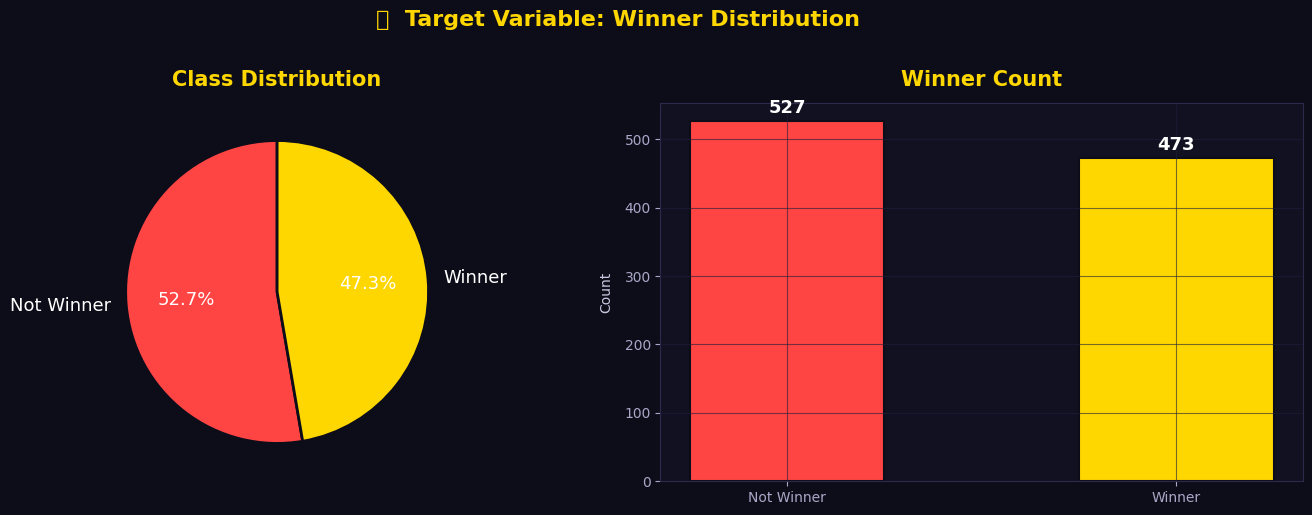

 Saved plot_01_class_distribution.png


In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d0d1a')

labels = ['Not Winner', 'Winner']
sizes  = train['winner'].value_counts().values
colors = [RED, GOLD]
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, autopct='%1.1f%%', colors=colors,
    startangle=90, textprops={'color': 'white', 'fontsize': 13},
    wedgeprops={'edgecolor': '#0d0d1a', 'linewidth': 2})
for at in autotexts:
    at.set_fontsize(13); at.set_color('white')
axes[0].set_title('Class Distribution', color=GOLD, fontsize=15, fontweight='bold')

counts = train['winner'].value_counts()
bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='#0d0d1a', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', color='white', fontsize=13, fontweight='bold')
axes[1].set_title('Winner Count', color=GOLD, fontsize=15, fontweight='bold')
axes[1].set_ylabel('Count', color='#c8c8e0')

plt.suptitle('🏆  Target Variable: Winner Distribution', color=GOLD, fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print(" Saved plot_01_class_distribution.png")


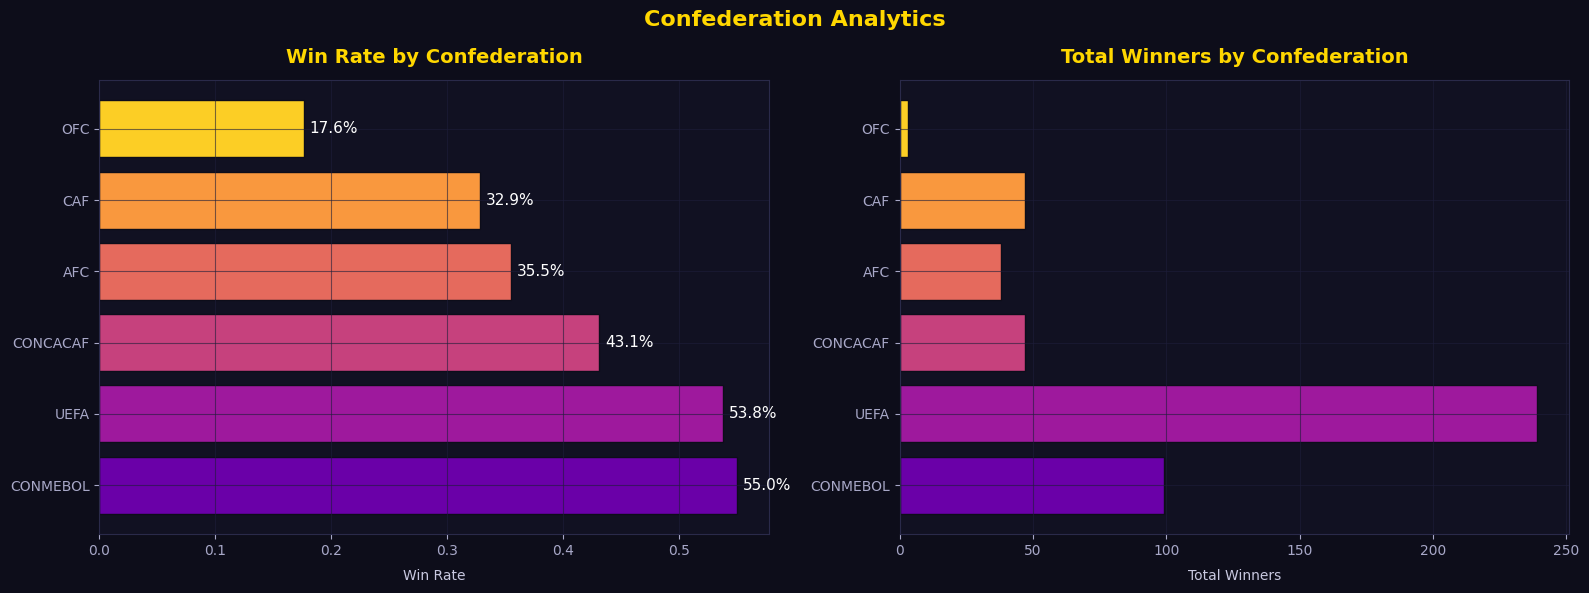

In [5]:
conf_win = train.groupby('confederation')['winner'].agg(['sum','count']).reset_index()
conf_win.columns = ['confederation', 'winners', 'total']
conf_win['win_rate'] = conf_win['winners'] / conf_win['total']
conf_win = conf_win.sort_values('win_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d1a')

bar_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(conf_win)))
axes[0].barh(conf_win['confederation'], conf_win['win_rate'],
             color=bar_colors, edgecolor='#0d0d1a', linewidth=1)
axes[0].set_xlabel('Win Rate', color='#c8c8e0')
axes[0].set_title('Win Rate by Confederation', color=GOLD, fontsize=14, fontweight='bold')
for i, (val, name) in enumerate(zip(conf_win['win_rate'], conf_win['confederation'])):
    axes[0].text(val + 0.005, i, f'{val:.1%}', va='center', color='white', fontsize=11)

axes[1].barh(conf_win['confederation'], conf_win['winners'],
             color=bar_colors, edgecolor='#0d0d1a', linewidth=1)
axes[1].set_xlabel('Total Winners', color='#c8c8e0')
axes[1].set_title('Total Winners by Confederation', color=GOLD, fontsize=14, fontweight='bold')

plt.suptitle('Confederation Analytics', color=GOLD, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_confederation.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


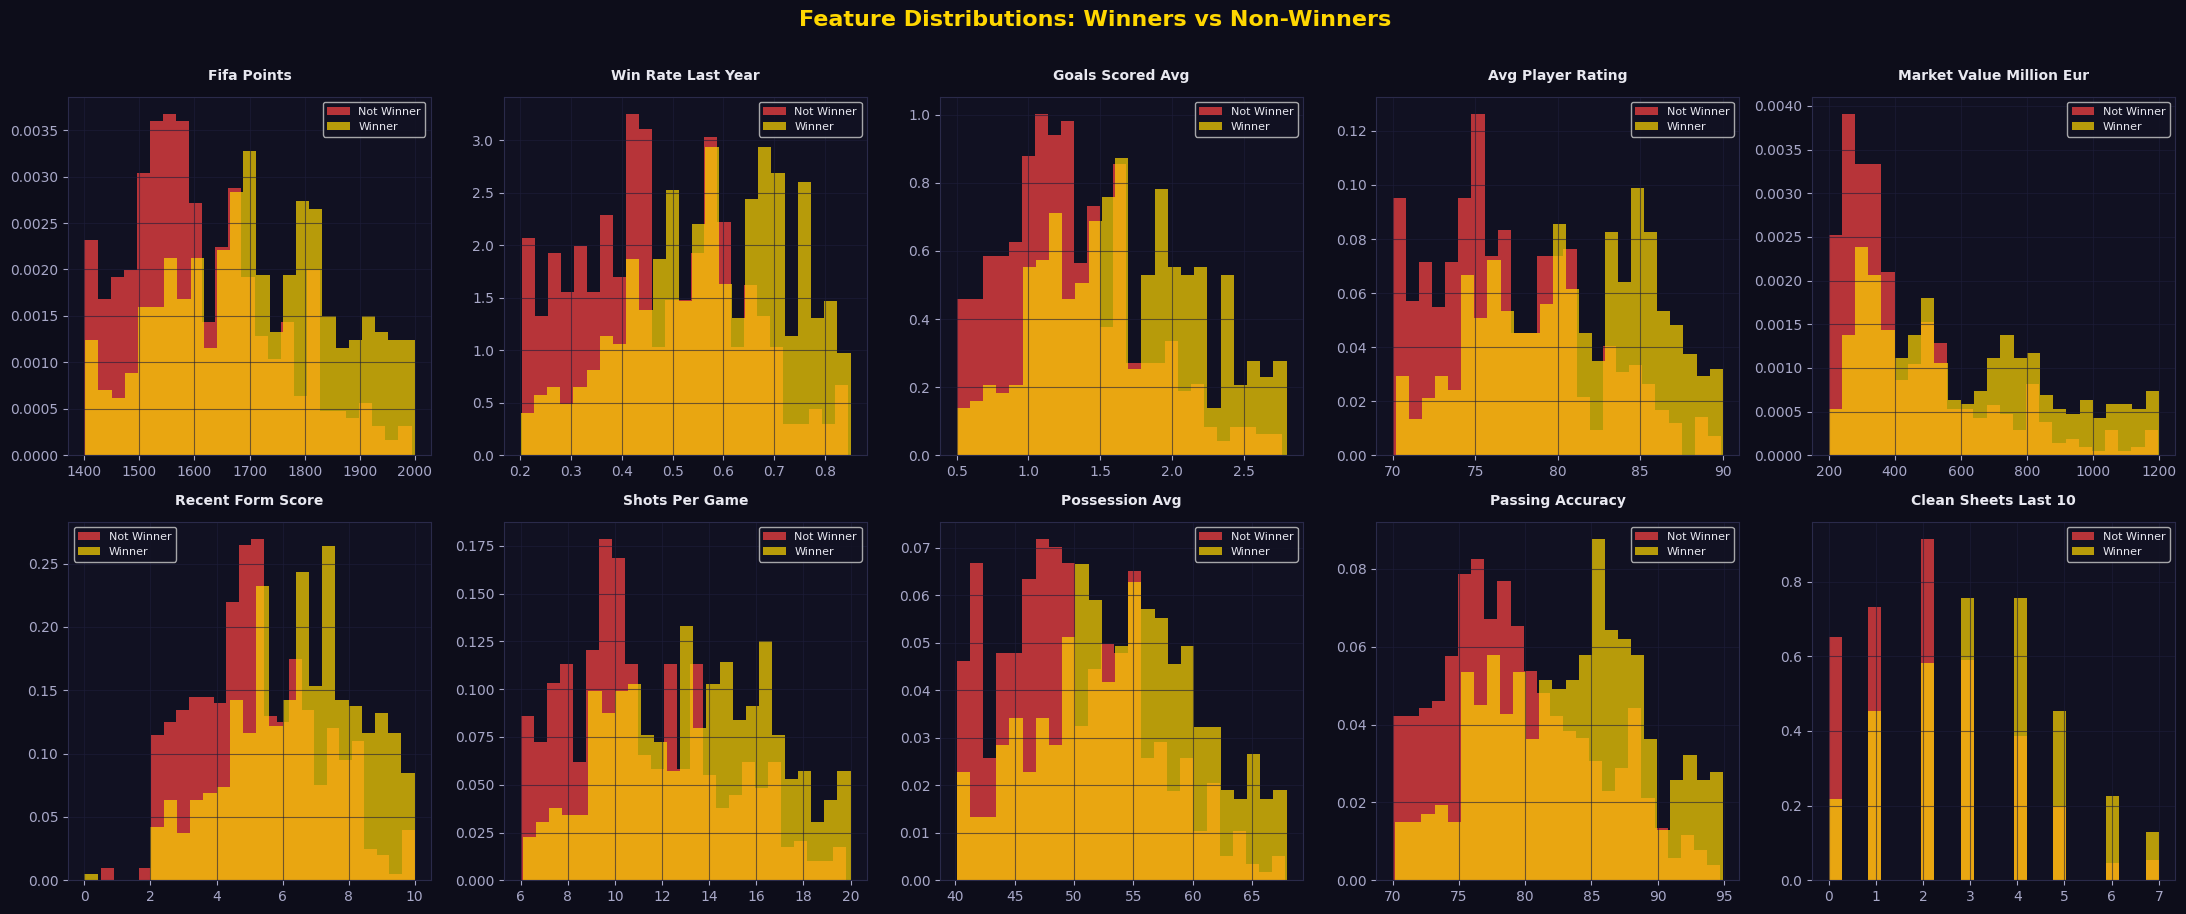

In [6]:

num_features = ['fifa_points','win_rate_last_year','goals_scored_avg',
                'avg_player_rating','market_value_million_eur','recent_form_score',
                'shots_per_game','possession_avg','passing_accuracy','clean_sheets_last_10']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.patch.set_facecolor('#0d0d1a')
axes = axes.flatten()

winners     = train[train['winner'] == 1]
non_winners = train[train['winner'] == 0]

for i, feat in enumerate(num_features):
    ax = axes[i]
    ax.hist(non_winners[feat], bins=25, alpha=0.7, color=RED,   label='Not Winner', density=True)
    ax.hist(winners[feat],     bins=25, alpha=0.7, color=GOLD,  label='Winner',     density=True)
    ax.set_title(feat.replace('_',' ').title(), color='#e8e8f0', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Winners vs Non-Winners',
             color=GOLD, fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_03_feature_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


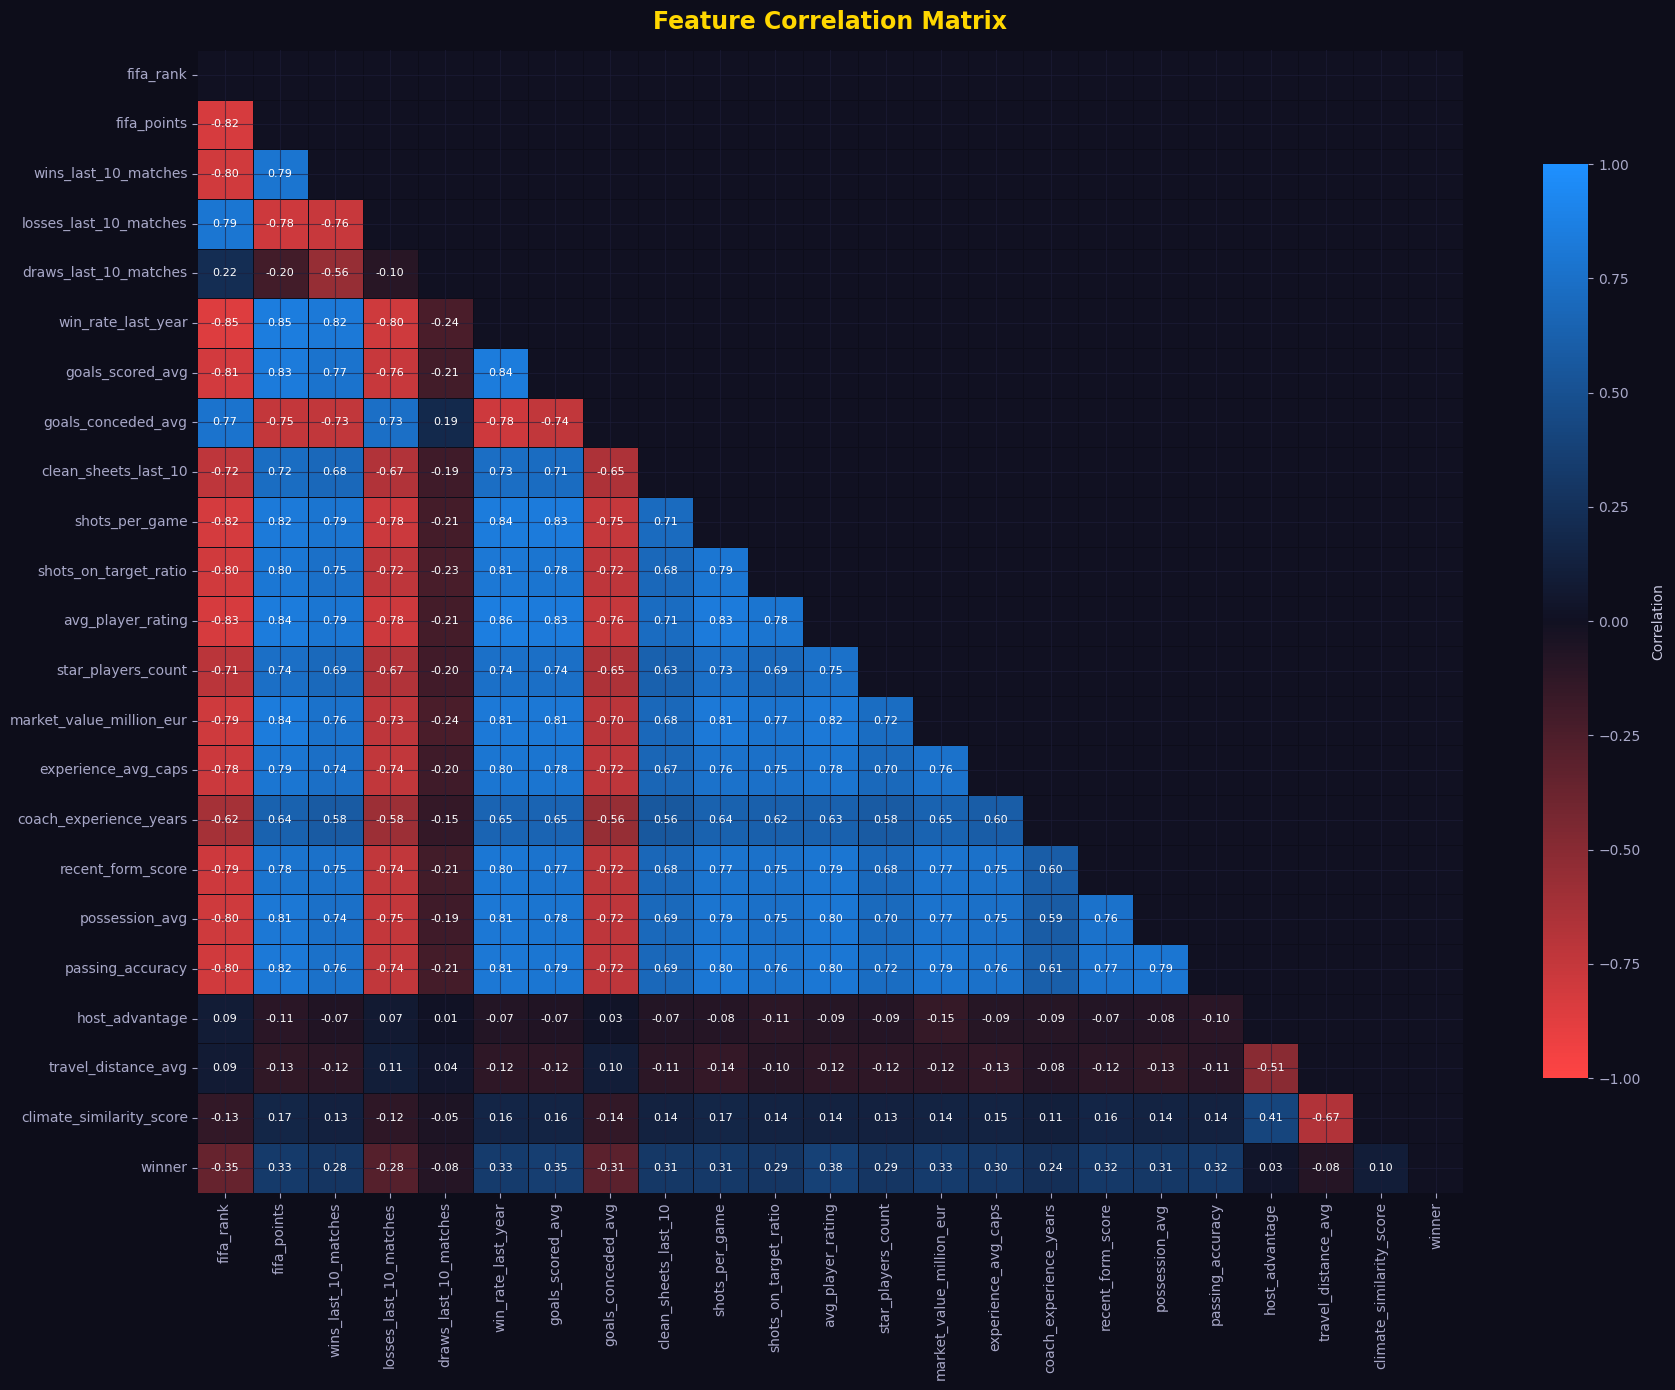

In [7]:

num_cols = train.select_dtypes(include=np.number).columns.tolist()
corr     = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#111122')

cmap = LinearSegmentedColormap.from_list('custom',
       ['#ff4444','#111122','#1e90ff'], N=256)
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            ax=ax, annot=True, fmt='.2f', annot_kws={'size': 8, 'color': 'white'},
            linewidths=0.5, linecolor='#0d0d1a',
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

ax.set_title('Feature Correlation Matrix', color=GOLD, fontsize=17, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_04_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


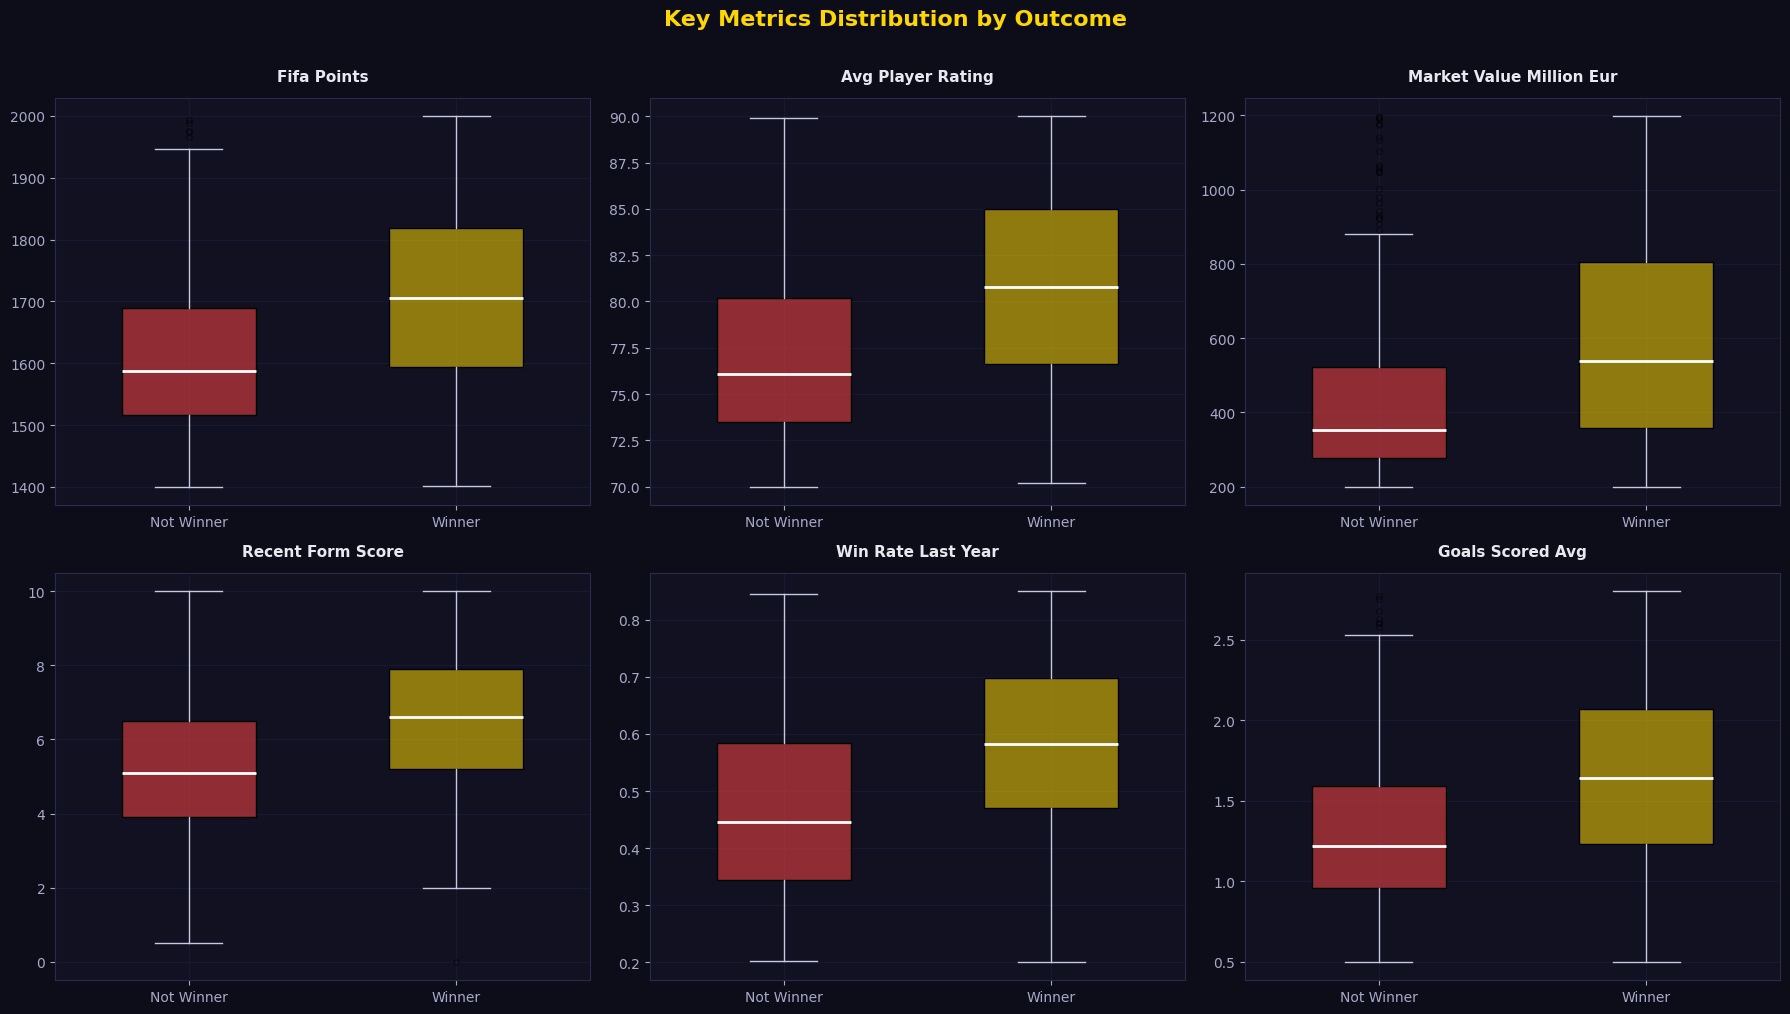

In [8]:

key_features = ['fifa_points','avg_player_rating','market_value_million_eur',
                'recent_form_score','win_rate_last_year','goals_scored_avg']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0d0d1a')
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    data_w  = winners[feat].dropna()
    data_nw = non_winners[feat].dropna()
    bp = ax.boxplot([data_nw, data_w], patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#c8c8e0'),
                    capprops=dict(color='#c8c8e0'),
                    flierprops=dict(marker='o', color='gray', alpha=0.4, markersize=4))
    bp['boxes'][0].set_facecolor(RED + '88')
    bp['boxes'][1].set_facecolor(GOLD + '88')
    ax.set_xticks([1, 2], ['Not Winner', 'Winner'])
    ax.set_title(feat.replace('_',' ').title(), color='#e8e8f0', fontsize=11, fontweight='bold')
plt.suptitle('Key Metrics Distribution by Outcome',
             color=GOLD, fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_05_boxplots.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


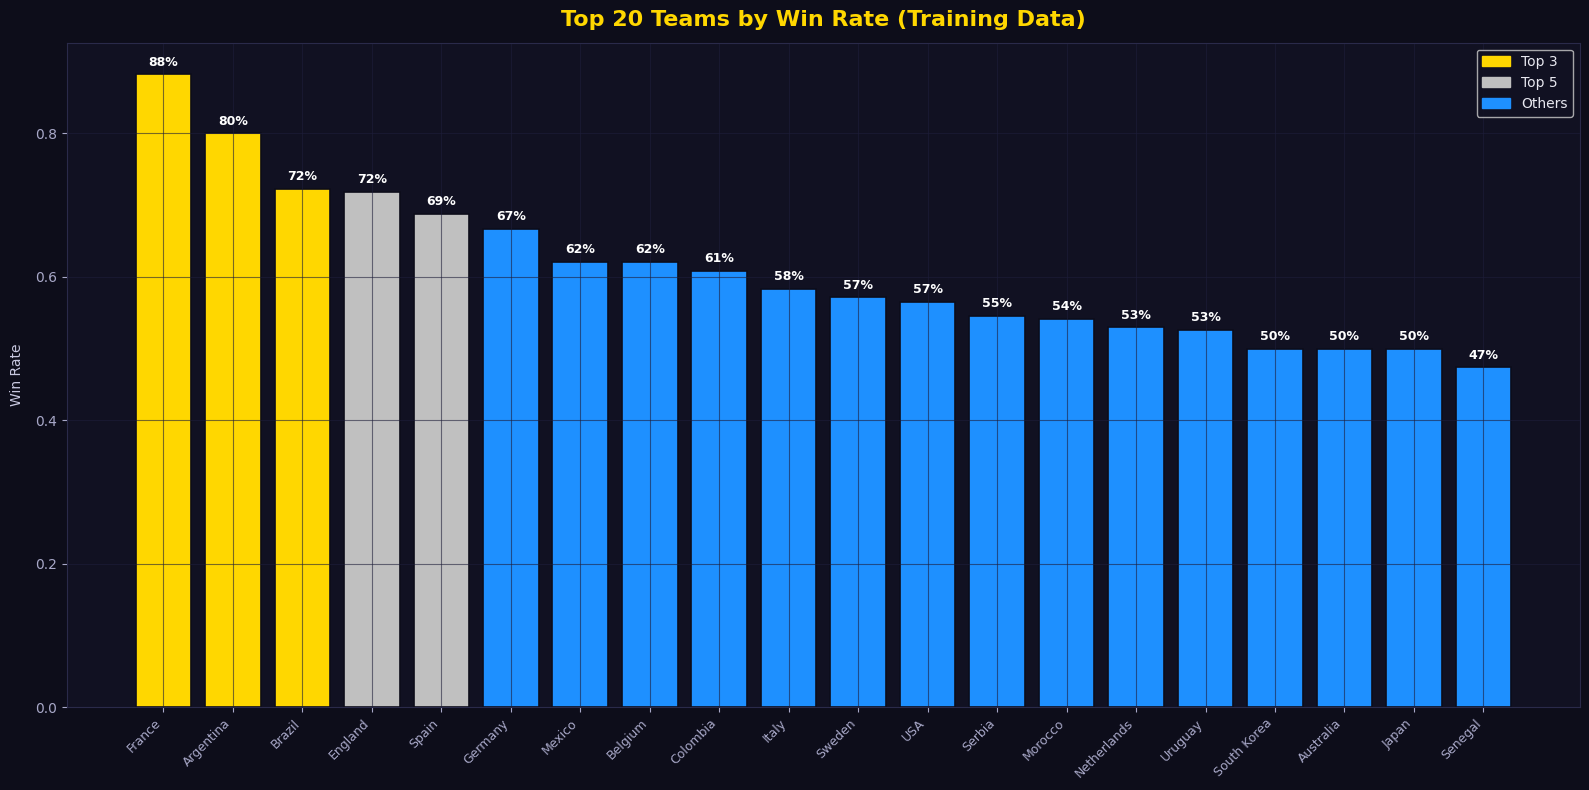

In [10]:

team_win = train.groupby('team_name')['winner'].agg(['mean','sum','count']).reset_index()
team_win.columns = ['team_name','win_rate','wins','matches']
team_win = team_win[team_win['matches'] >= 5].sort_values('win_rate', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#111122')
colors_bar = [GOLD if i < 3 else (SILVER if i < 5 else BLUE) for i in range(len(team_win))]
bars = ax.bar(team_win['team_name'], team_win['win_rate'],
              color=colors_bar, edgecolor='#0d0d1a', linewidth=1.2)
for bar, val in zip(bars, team_win['win_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val:.0%}', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

ax.set_xticklabels(team_win['team_name'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Win Rate', color='#c8c8e0')
ax.set_title('Top 20 Teams by Win Rate (Training Data)',
             color=GOLD, fontsize=16, fontweight='bold')

gold_p   = mpatches.Patch(color=GOLD,   label='Top 3')
silver_p = mpatches.Patch(color=SILVER, label='Top 5')
blue_p   = mpatches.Patch(color=BLUE,   label='Others')
ax.legend(handles=[gold_p, silver_p, blue_p], loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('plot_06_top_teams.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


In [11]:

def engineer_features(df):
    df = df.copy()
    df['strength_index']      = (df['fifa_points'] +
                                  df['recent_form_score'] * 50 +
                                  df['avg_player_rating'] * 10)
    df['goal_efficiency']     = df['goals_scored_avg'] / df['goals_conceded_avg'].clip(lower=0.1)
    df['attack_potency']      = (df['shots_per_game'] *
                                  df['shots_on_target_ratio'] *
                                  df['goals_scored_avg'])
    df['defensive_solidity']  = df['clean_sheets_last_10'] / (df['goals_conceded_avg'] + 0.5)
    df['squad_quality']       = (df['avg_player_rating'] * 0.4 +
                                  (df['market_value_million_eur'] / 1200) * 100 * 0.3 +
                                  (df['experience_avg_caps'] / 65) * 100 * 0.3)
    df['form_consistency']    = df['win_rate_last_year'] * df['recent_form_score']
    df['possession_dominance']= df['possession_avg'] * df['passing_accuracy'] / 100
    df['star_power']          = df['star_players_count'] * df['market_value_million_eur']
    df['contextual_advantage']= (df['host_advantage'] * 10 +
                                  df['climate_similarity_score'] * 5 -
                                  df['travel_distance_avg'] * 0.5)
    df['goals_diff_avg']      = df['goals_scored_avg'] - df['goals_conceded_avg']
    df['consistency_score']   = df['wins_last_10_matches'] - df['losses_last_10_matches']
    df['experience_rank']     = df['experience_avg_caps'] * df['fifa_points'] / 1000
    conf_map = {'UEFA':1,'CONMEBOL':2,'CAF':3,'CONCACAF':4,'AFC':5,'OFC':6}
    df['conf_code']           = df['confederation'].map(conf_map).fillna(0)
    return df
X_all  = engineer_features(train)
X_test = engineer_features(test)

num_feats = [c for c in X_all.columns
             if c not in ['team_name','country_code','confederation','winner']
             and X_all[c].dtype != object]

X = X_all[num_feats].fillna(X_all[num_feats].mean())
y = train['winner']
X_test_fe = X_test[num_feats].fillna(X_test[num_feats].mean())

print(f"Features after engineering: {len(num_feats)}")
print(f"X shape: {X.shape}  |  X_test shape: {X_test_fe.shape}")
print("\nNew features:", [f for f in num_feats if f not in train.columns])


Features after engineering: 35
X shape: (1000, 35)  |  X_test shape: (250, 35)

New features: ['strength_index', 'goal_efficiency', 'attack_potency', 'defensive_solidity', 'squad_quality', 'form_consistency', 'possession_dominance', 'star_power', 'contextual_advantage', 'goals_diff_avg', 'consistency_score', 'experience_rank', 'conf_code']


In [12]:
scaler = StandardScaler()
X_scaled      = pd.DataFrame(scaler.fit_transform(X),      columns=num_feats)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_fe),  columns=num_feats)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_s, X_val_s = X_scaled.iloc[X_train.index], X_scaled.iloc[X_val.index]

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")
print(f"Class balance — Train: {y_train.value_counts().to_dict()}  |  Val: {y_val.value_counts().to_dict()}")

Train: (800, 35)  |  Val: (200, 35)
Class balance — Train: {0: 422, 1: 378}  |  Val: {0: 105, 1: 95}


In [13]:
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=600, learning_rate=0.04, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    min_child_weight=3, gamma=0.1,
    eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)], verbose=False)

print("Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=600, learning_rate=0.04, max_depth=6,
    num_leaves=40, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)])

print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=400, max_depth=12,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=5, subsample=0.8, random_state=42)
gb_model.fit(X_train, y_train)

print("\nAll models trained!")


Training XGBoost...
Training LightGBM...
Training Random Forest...
Training Gradient Boosting...

All models trained!


In [14]:
models = {
    'XGBoost'          : xgb_model,
    'LightGBM'         : lgb_model,
    'Random Forest'    : rf_model,
    'Gradient Boosting': gb_model,
}

results = {}
for name, model in models.items():
    prob = model.predict_proba(X_val)[:,1]
    pred = model.predict(X_val)
    results[name] = {
        'AUC'     : roc_auc_score(y_val, prob),
        'Accuracy': accuracy_score(y_val, pred),
        'proba'   : prob,
        'pred'    : pred,
    }
    print(f"{name:20s}  AUC: {results[name]['AUC']:.4f}  Acc: {results[name]['Accuracy']:.4f}")
ens_proba = (0.35*results['XGBoost']['proba'] +
             0.35*results['LightGBM']['proba'] +
             0.20*results['Random Forest']['proba'] +
             0.10*results['Gradient Boosting']['proba'])
ens_pred  = (ens_proba >= 0.5).astype(int)
ens_auc   = roc_auc_score(y_val, ens_proba)
ens_acc   = accuracy_score(y_val, ens_pred)
results['Ensemble'] = {'AUC':ens_auc,'Accuracy':ens_acc,'proba':ens_proba,'pred':ens_pred}
print(f"{'Ensemble':20s}  AUC: {ens_auc:.4f}  Acc: {ens_acc:.4f}")

XGBoost               AUC: 0.6534  Acc: 0.5950
LightGBM              AUC: 0.6539  Acc: 0.6400
Random Forest         AUC: 0.6711  Acc: 0.6350
Gradient Boosting     AUC: 0.6376  Acc: 0.6100
Ensemble              AUC: 0.6565  Acc: 0.6300


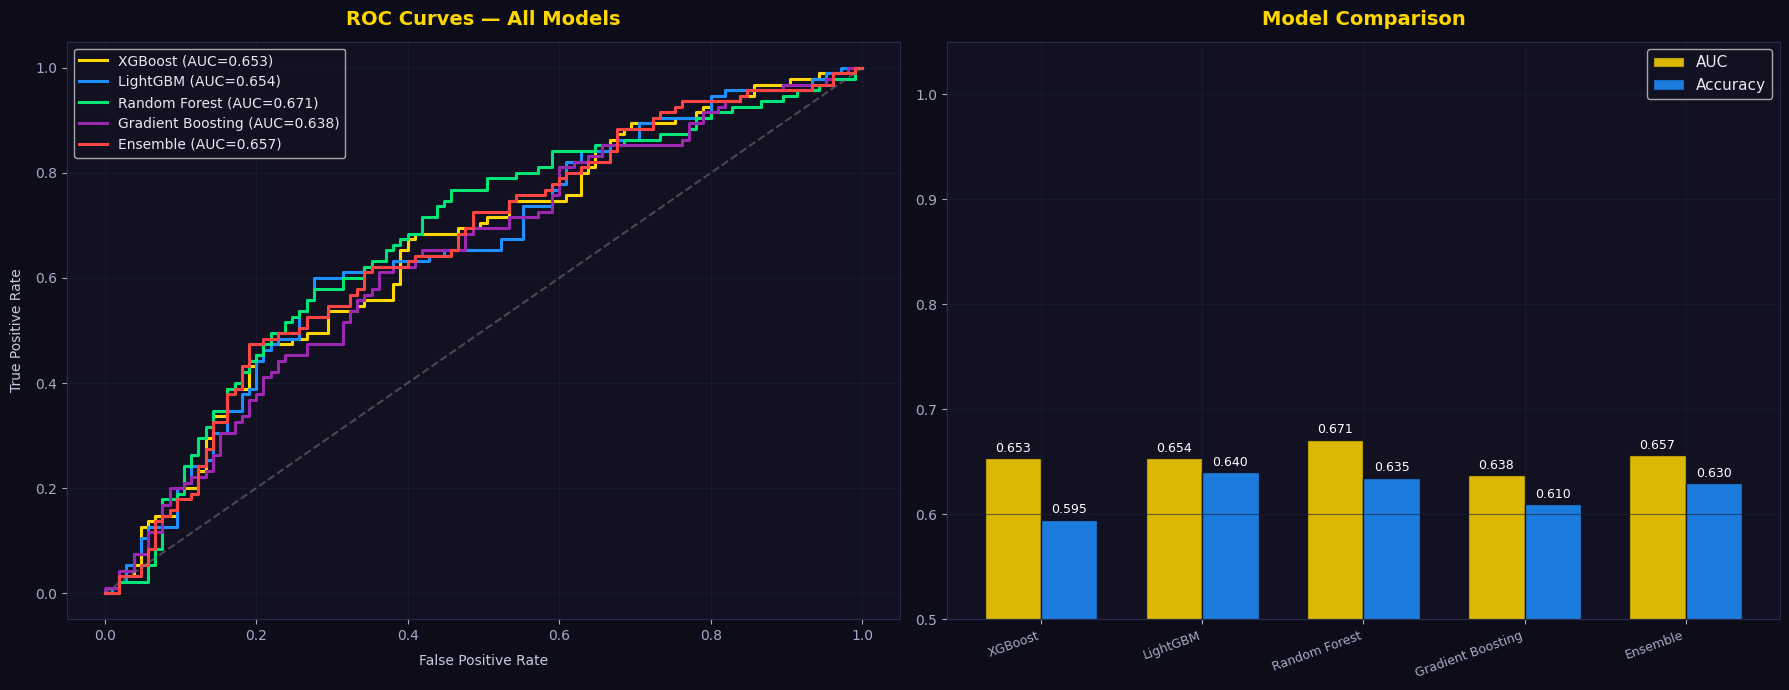

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0d0d1a')

palette = [GOLD, BLUE, GREEN, PURPLE, RED]
for (name, res), col in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_val, res['proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['AUC']:.3f})",
                 color=col, linewidth=2.2)

axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', color=GOLD, fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)

names   = list(results.keys())
aucs    = [results[n]['AUC']      for n in names]
accs    = [results[n]['Accuracy'] for n in names]
x       = np.arange(len(names)); w=0.35
bars1 = axes[1].bar(x - w/2, aucs, w, label='AUC',      color=GOLD,  alpha=0.85, edgecolor='#0d0d1a')
bars2 = axes[1].bar(x + w/2, accs, w, label='Accuracy', color=BLUE,  alpha=0.85, edgecolor='#0d0d1a')
for bar in list(bars1)+list(bars2):
    h = bar.get_height()
    axes[1].text(bar.get_x()+bar.get_width()/2, h+0.003,
                 f'{h:.3f}', ha='center', va='bottom', color='white', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_title('Model Comparison', color=GOLD, fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('plot_07_roc_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


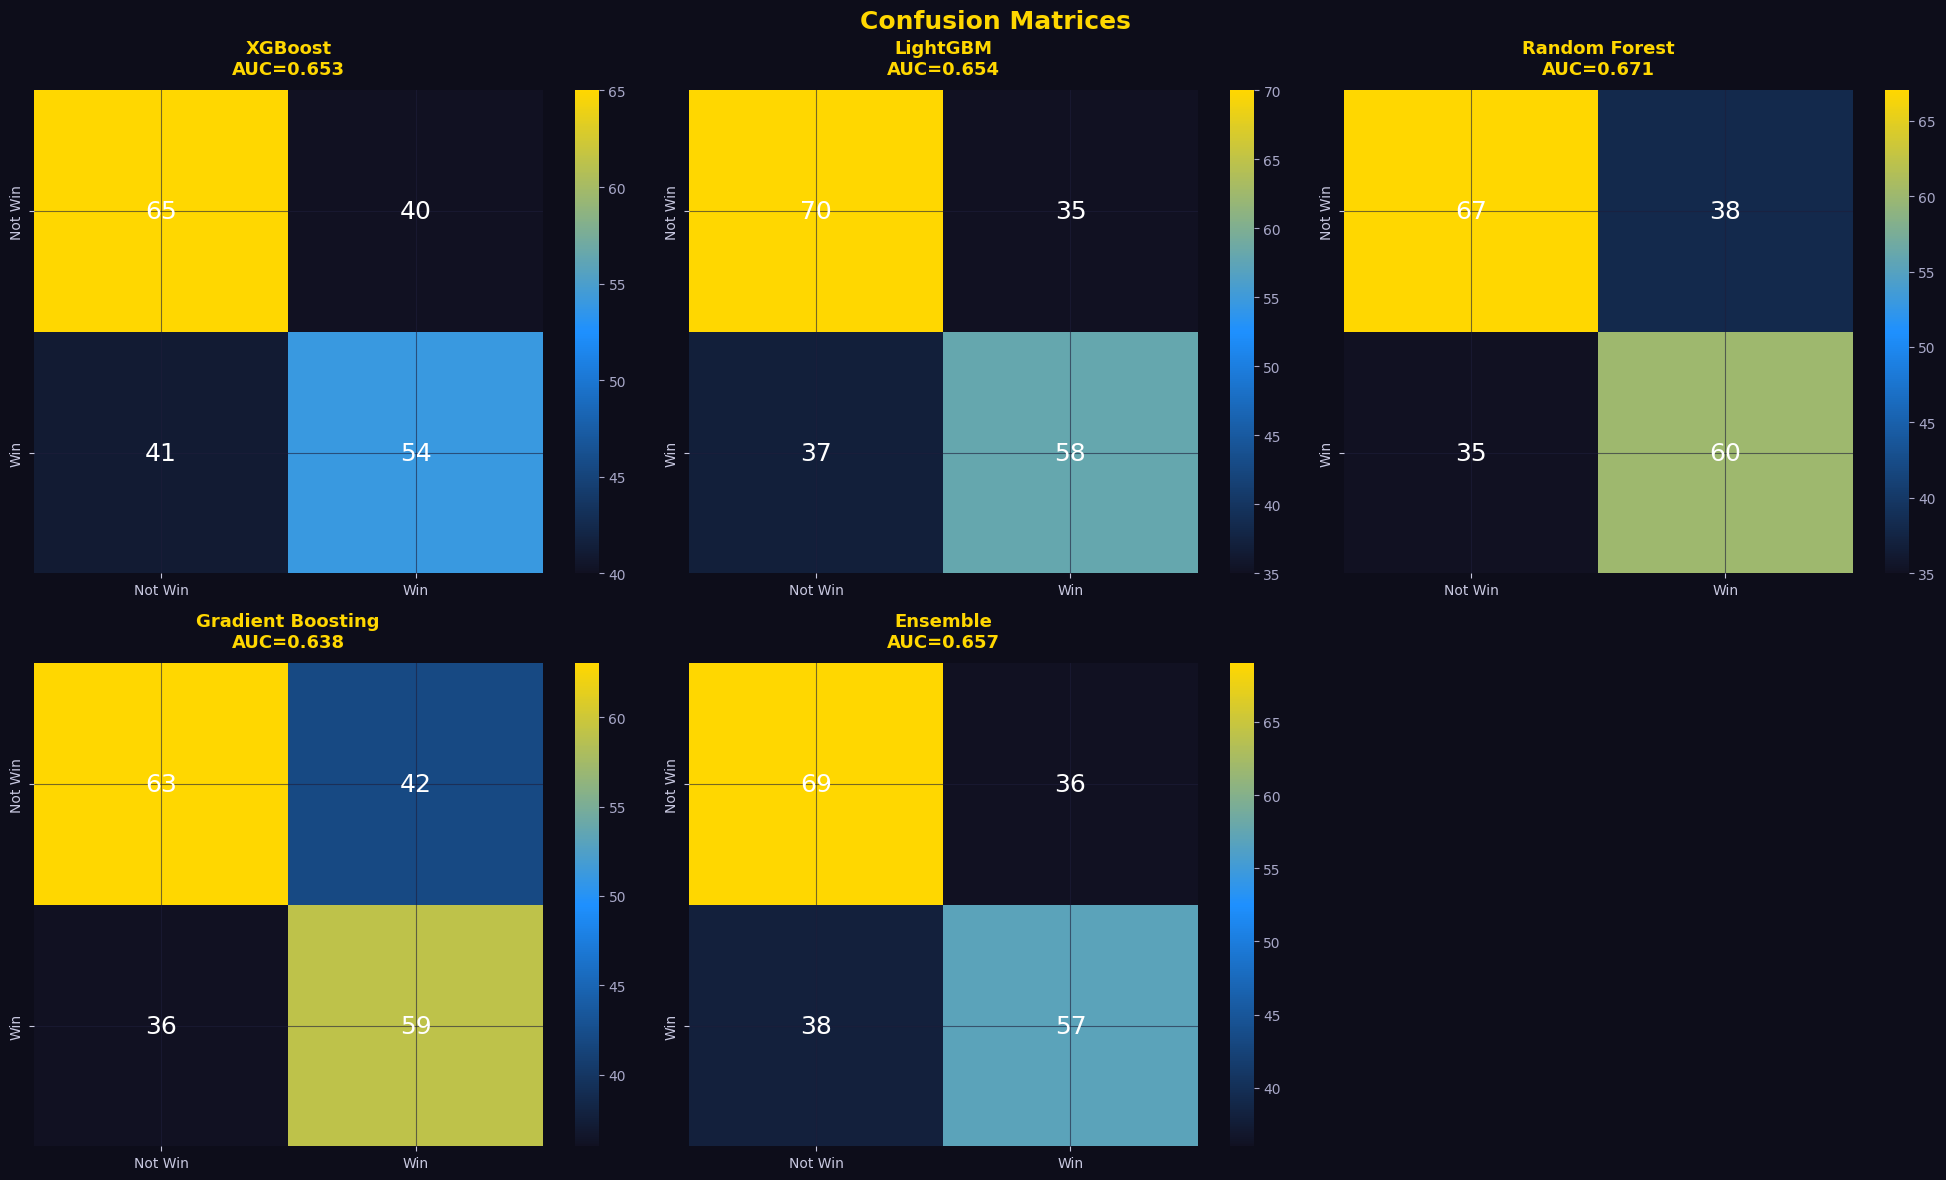

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor('#0d0d1a')
axes = axes.flatten()

cmap_cm = LinearSegmentedColormap.from_list('cm', ['#111122','#1e90ff','#FFD700'])

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_val, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_cm,
                ax=axes[i], annot_kws={'size': 18, 'color': 'white'},
                xticklabels=['Not Win','Win'],
                yticklabels=['Not Win','Win'])
    axes[i].set_title(f'{name}\nAUC={res["AUC"]:.3f}',
                      color=GOLD, fontsize=13, fontweight='bold')
    axes[i].tick_params(colors='#c8c8e0')
axes[-1].set_visible(False)  
plt.suptitle('Confusion Matrices', color=GOLD, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_08_confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


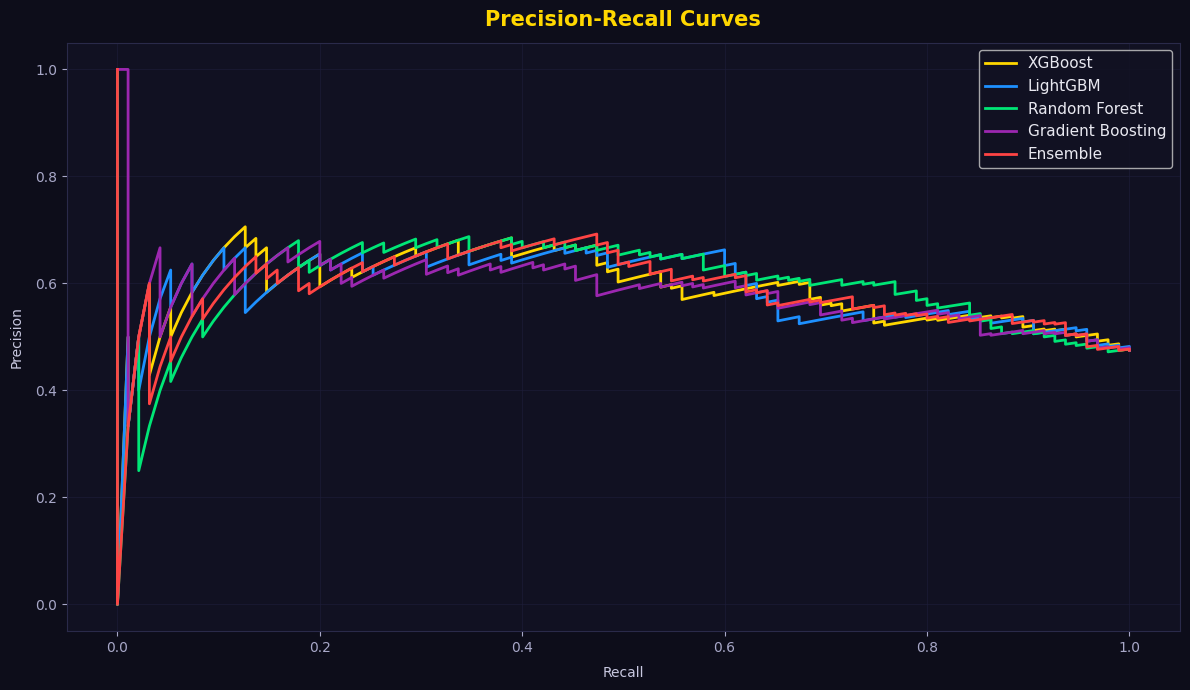

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0d0d1a')

for (name, res), col in zip(results.items(), palette):
    prec, rec, _ = precision_recall_curve(y_val, res['proba'])
    ax.plot(rec, prec, label=name, color=col, linewidth=2)
ax.set_xlabel('Recall');  ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', color=GOLD, fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_09_precision_recall.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

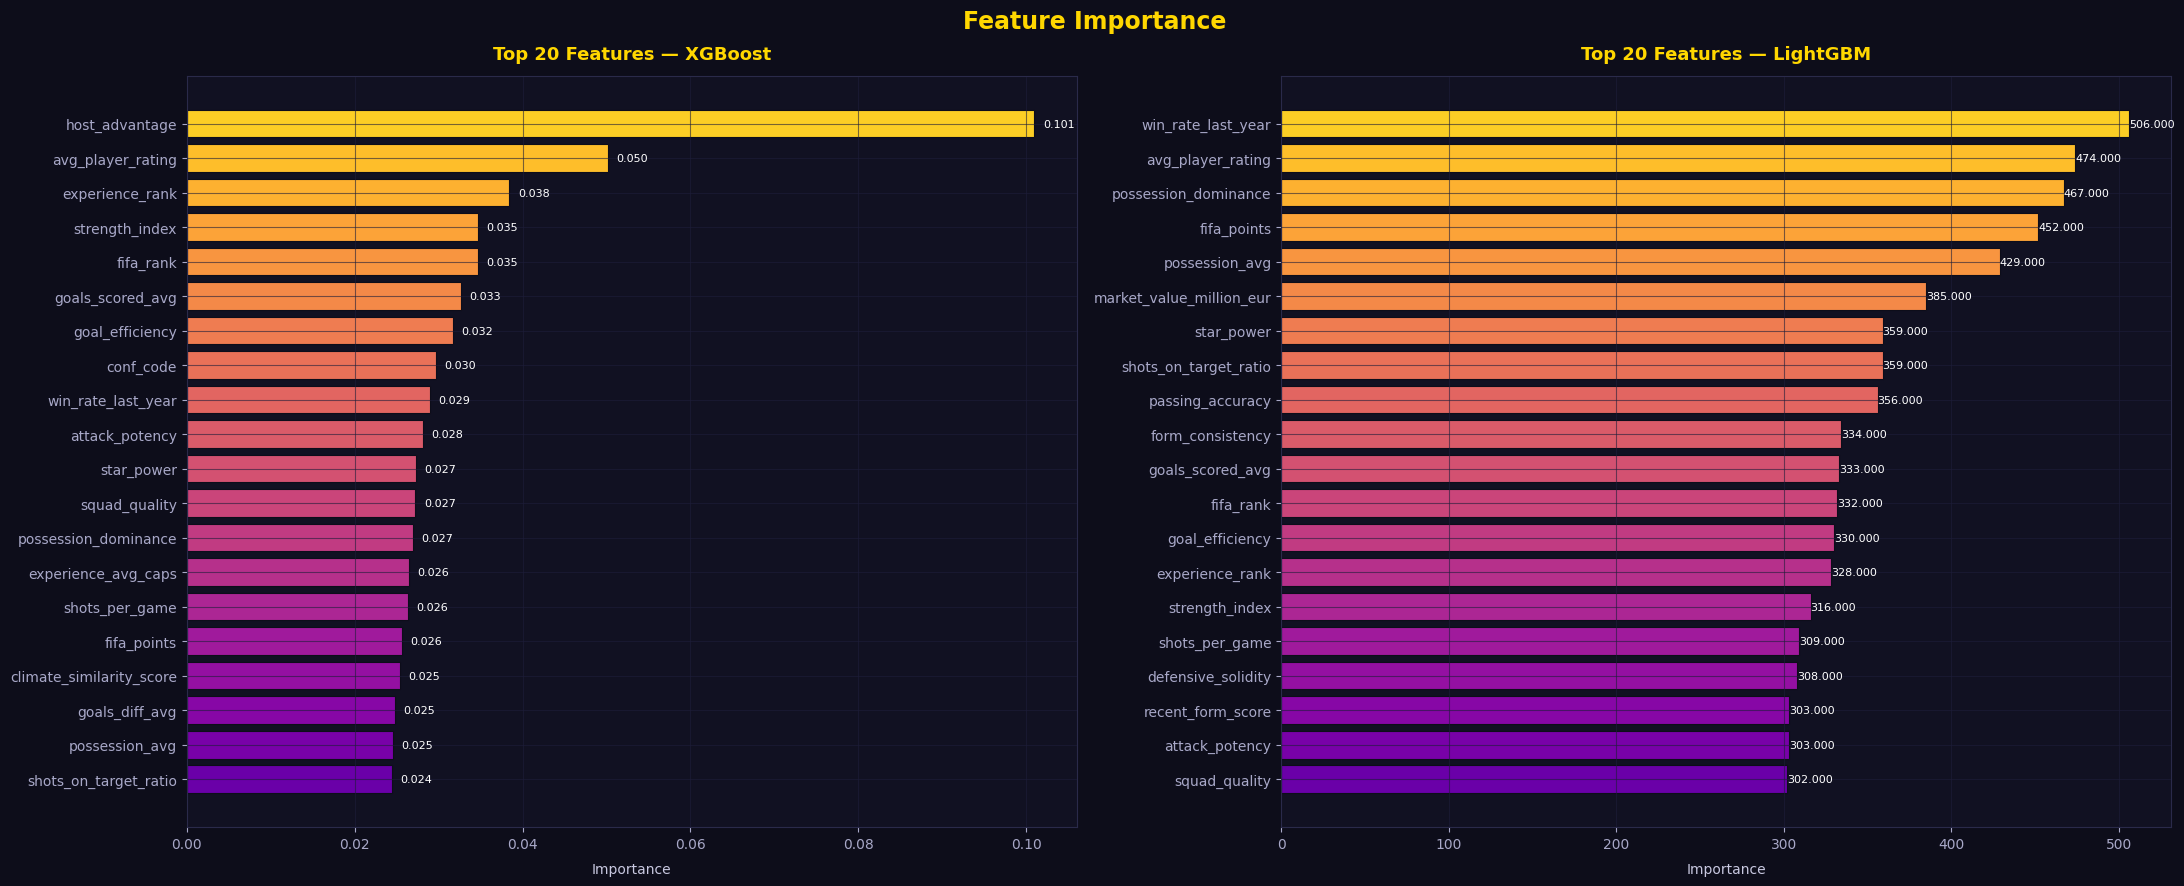

In [18]:
imp_xgb = pd.DataFrame({
    'feature'   : num_feats,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

imp_lgb = pd.DataFrame({
    'feature'   : num_feats,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.patch.set_facecolor('#0d0d1a')

for ax, df, title in zip(axes, [imp_xgb, imp_lgb], ['XGBoost', 'LightGBM']):
    colors_f = plt.cm.plasma(np.linspace(0.2, 0.9, len(df)))
    ax.barh(df['feature'][::-1], df['importance'][::-1],
            color=colors_f, edgecolor='#0d0d1a', linewidth=0.8)
    ax.set_title(f'Top 20 Features — {title}', color=GOLD, fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    for i, (val, feat) in enumerate(zip(df['importance'][::-1], df['feature'][::-1])):
        ax.text(val + 0.001, i, f'{val:.3f}', va='center', color='white', fontsize=8)

plt.suptitle('Feature Importance', color=GOLD, fontsize=17, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_10_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

XGBoost       CV AUC: 0.6577 ± 0.0353  |  Folds: [0.6087 0.6225 0.6743 0.6884 0.6947]
LightGBM      CV AUC: 0.6465 ± 0.0320  |  Folds: [0.6036 0.6143 0.6575 0.6725 0.6847]
RF            CV AUC: 0.6920 ± 0.0490  |  Folds: [0.6422 0.6376 0.6837 0.7385 0.758 ]


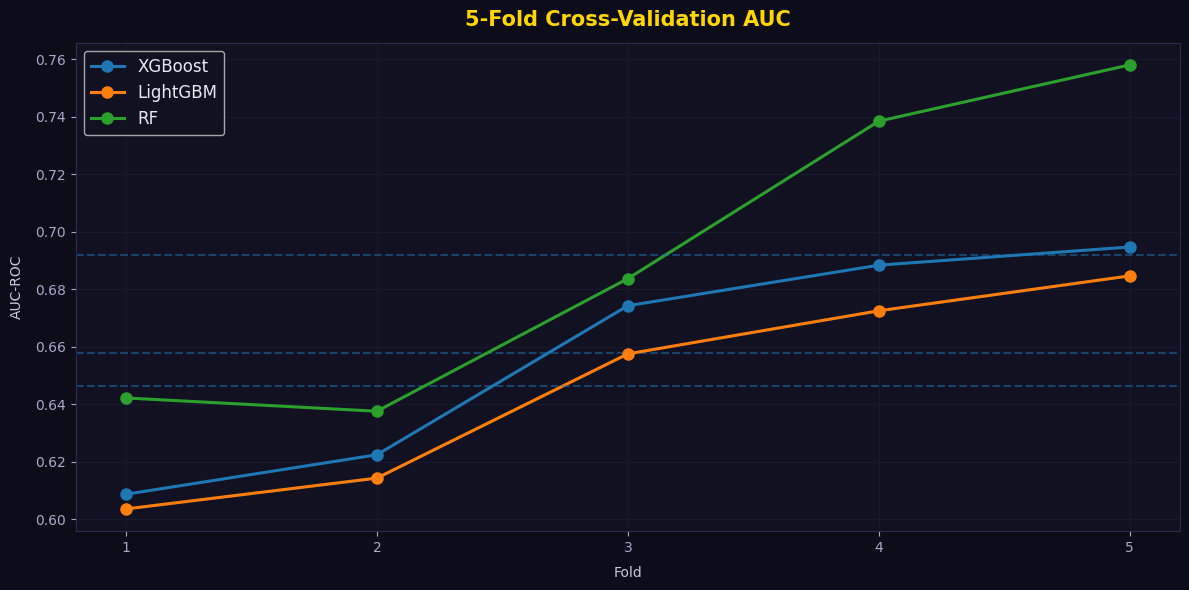

In [19]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in {'XGBoost':xgb_model,'LightGBM':lgb_model,'RF':rf_model}.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:12s}  CV AUC: {scores.mean():.4f} ± {scores.std():.4f}  |  Folds: {np.round(scores,4)}")

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#111122')

for i, (name, scores) in enumerate(cv_results.items()):
    ax.plot(range(1,6), scores, 'o-', label=name, linewidth=2.2, markersize=8)
    ax.axhline(scores.mean(), linestyle='--', alpha=0.5)

ax.set_xlabel('Fold'); ax.set_ylabel('AUC-ROC')
ax.set_xticks(range(1,6))
ax.set_title('5-Fold Cross-Validation AUC', color=GOLD, fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plot_11_cross_validation.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

Calibrated XGB AUC: 0.6748


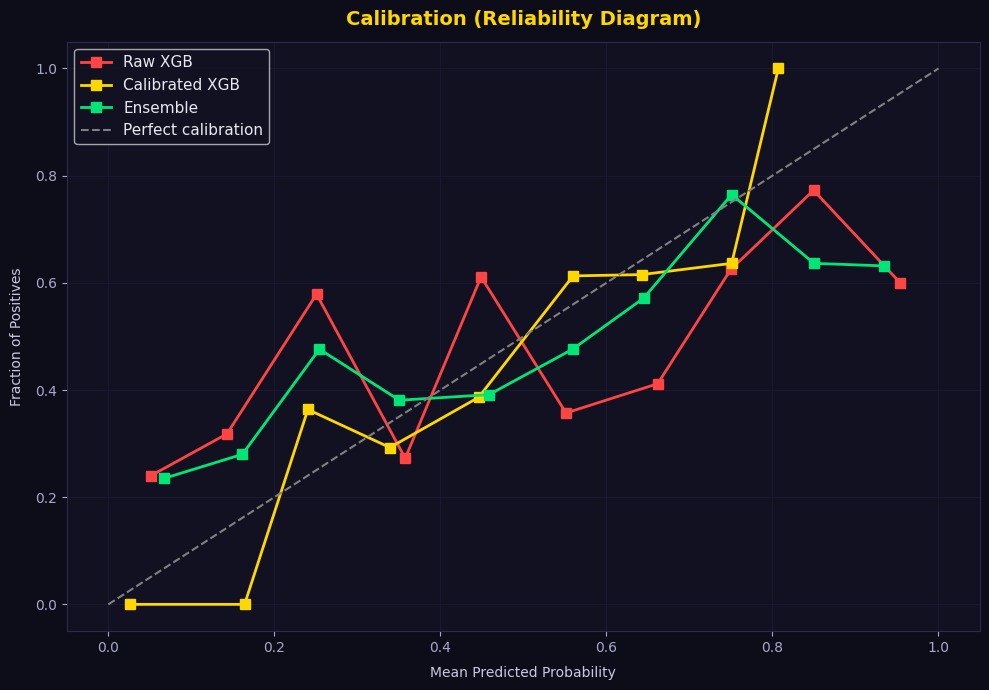

In [20]:

cal_xgb = CalibratedClassifierCV(xgb_model, cv=3, method='isotonic')
cal_xgb.fit(X_train, y_train)

cal_proba = cal_xgb.predict_proba(X_val)[:,1]
print(f"Calibrated XGB AUC: {roc_auc_score(y_val, cal_proba):.4f}")
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0d0d1a')

for name, prob, col in [('Raw XGB', results['XGBoost']['proba'], RED),
                         ('Calibrated XGB', cal_proba, GOLD),
                         ('Ensemble', ens_proba, GREEN)]:
    frac_pos, mean_pred = calibration_curve(y_val, prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', label=name, color=col, linewidth=2, markersize=7)
ax.plot([0,1],[0,1],'k--',color='gray', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration (Reliability Diagram)', color=GOLD, fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_12_calibration.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

In [21]:
final_xgb = xgb.XGBClassifier(
    n_estimators=600, learning_rate=0.04, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    min_child_weight=3, gamma=0.1, eval_metric='logloss',
    random_state=42, n_jobs=-1)
final_xgb.fit(X, y)

final_lgb = lgb.LGBMClassifier(
    n_estimators=600, learning_rate=0.04, max_depth=6,
    num_leaves=40, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1)
final_lgb.fit(X, y)

final_rf = RandomForestClassifier(
    n_estimators=400, max_depth=12, min_samples_split=5,
    min_samples_leaf=2, random_state=42, n_jobs=-1)
final_rf.fit(X, y)
test_p_xgb = final_xgb.predict_proba(X_test_fe)[:,1]
test_p_lgb = final_lgb.predict_proba(X_test_fe)[:,1]
test_p_rf  = final_rf.predict_proba(X_test_fe)[:,1]
test_proba = 0.40*test_p_xgb + 0.40*test_p_lgb + 0.20*test_p_rf

pred_df = test.copy()
pred_df['win_prob_xgb']      = test_p_xgb
pred_df['win_prob_lgb']      = test_p_lgb
pred_df['win_prob_rf']       = test_p_rf
pred_df['win_prob_ensemble'] = test_proba
pred_df['rank']              = pred_df['win_prob_ensemble'].rank(ascending=False).astype(int)
pred_df = pred_df.sort_values('win_prob_ensemble', ascending=False)

print("Predictions generated!")
print(f"\nTop 10 predicted winners:")
print(pred_df[['team_name','confederation','win_prob_ensemble','rank']].head(10).to_string(index=False))

Predictions generated!

Top 10 predicted winners:
team_name confederation  win_prob_ensemble  rank
   Brazil      CONMEBOL           0.957874     1
   Brazil      CONMEBOL           0.957101     2
  England          UEFA           0.956183     3
    Spain          UEFA           0.953833     4
   Brazil      CONMEBOL           0.950805     5
  England          UEFA           0.942642     6
Argentina      CONMEBOL           0.940246     7
   France          UEFA           0.934359     8
  England          UEFA           0.929998     9
    Japan           AFC           0.928851    10


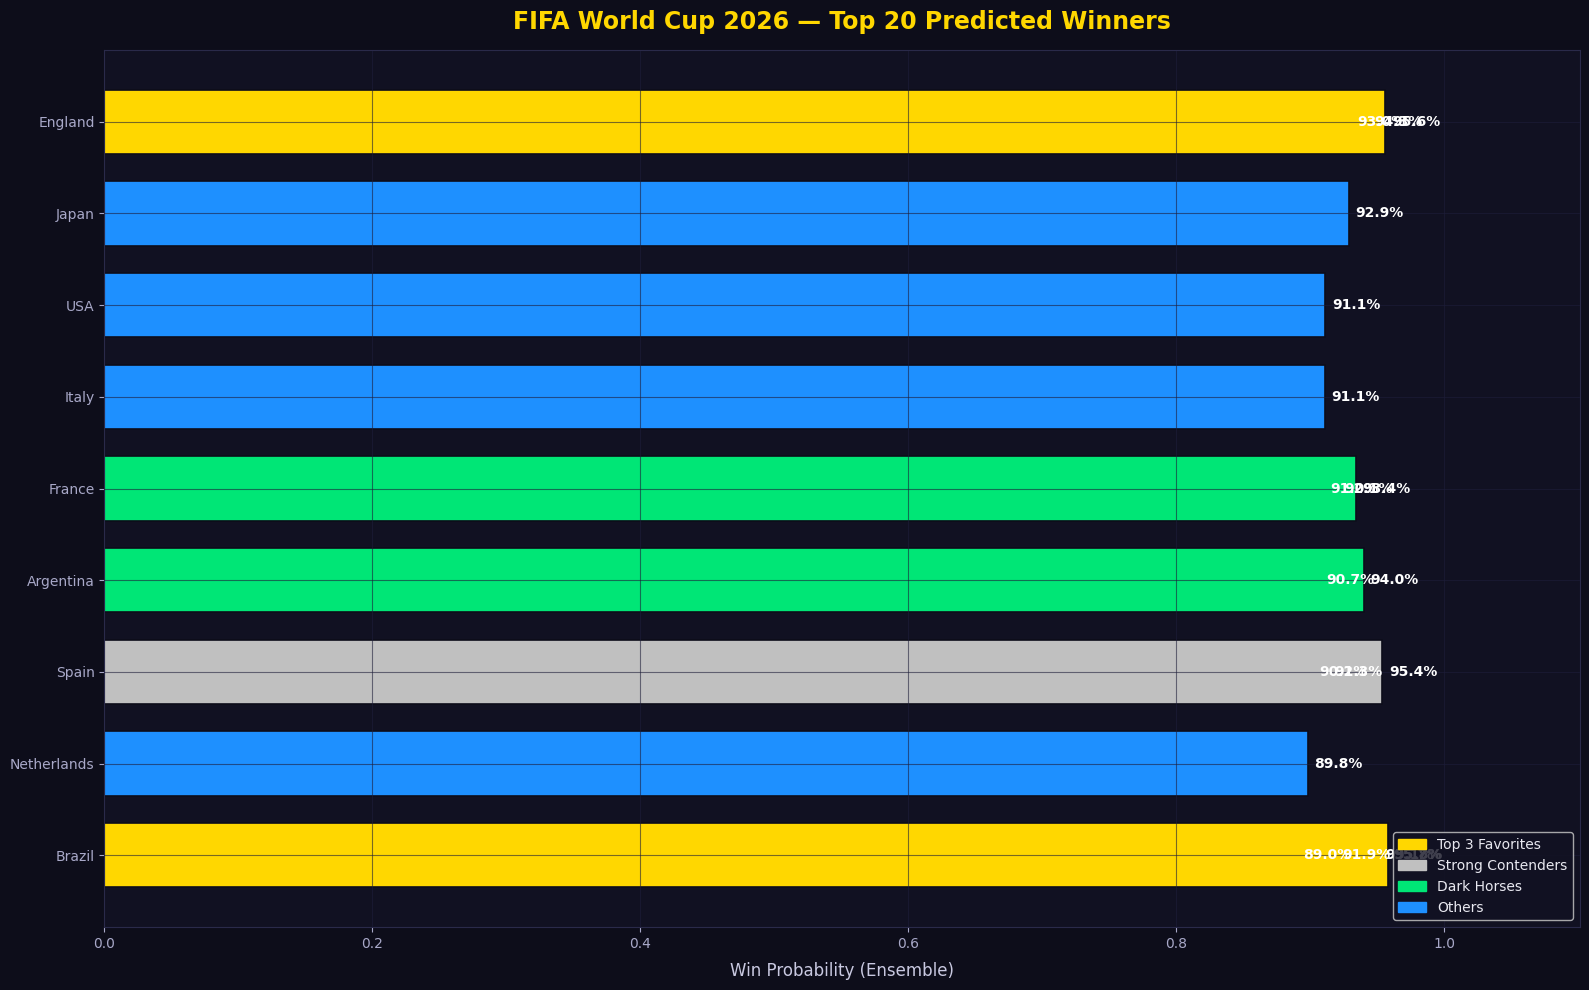

In [22]:
top20 = pred_df.head(20).sort_values('win_prob_ensemble')
fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#0d0d1a'); ax.set_facecolor('#111122')
bar_c = [GOLD if i >= 17 else (SILVER if i >= 15 else (GREEN if i >= 12 else BLUE))
         for i in range(len(top20))]
bars = ax.barh(top20['team_name'], top20['win_prob_ensemble'],
               color=bar_c, edgecolor='#0d0d1a', linewidth=1.2, height=0.7)

for bar, val in zip(bars, top20['win_prob_ensemble']):
    ax.text(val + 0.005, bar.get_y()+bar.get_height()/2,
            f'{val:.1%}', va='center', color='white', fontsize=10, fontweight='bold')

ax.set_xlabel('Win Probability (Ensemble)', fontsize=12)
ax.set_title('FIFA World Cup 2026 — Top 20 Predicted Winners',
             color=GOLD, fontsize=17, fontweight='bold', pad=15)

patches = [mpatches.Patch(color=GOLD,  label='Top 3 Favorites'),
           mpatches.Patch(color=SILVER,label='Strong Contenders'),
           mpatches.Patch(color=GREEN, label='Dark Horses'),
           mpatches.Patch(color=BLUE,  label='Others')]
ax.legend(handles=patches, fontsize=10, loc='lower right')
ax.set_xlim(0, top20['win_prob_ensemble'].max() * 1.15)

plt.tight_layout()
plt.savefig('plot_13_predictions_bar.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


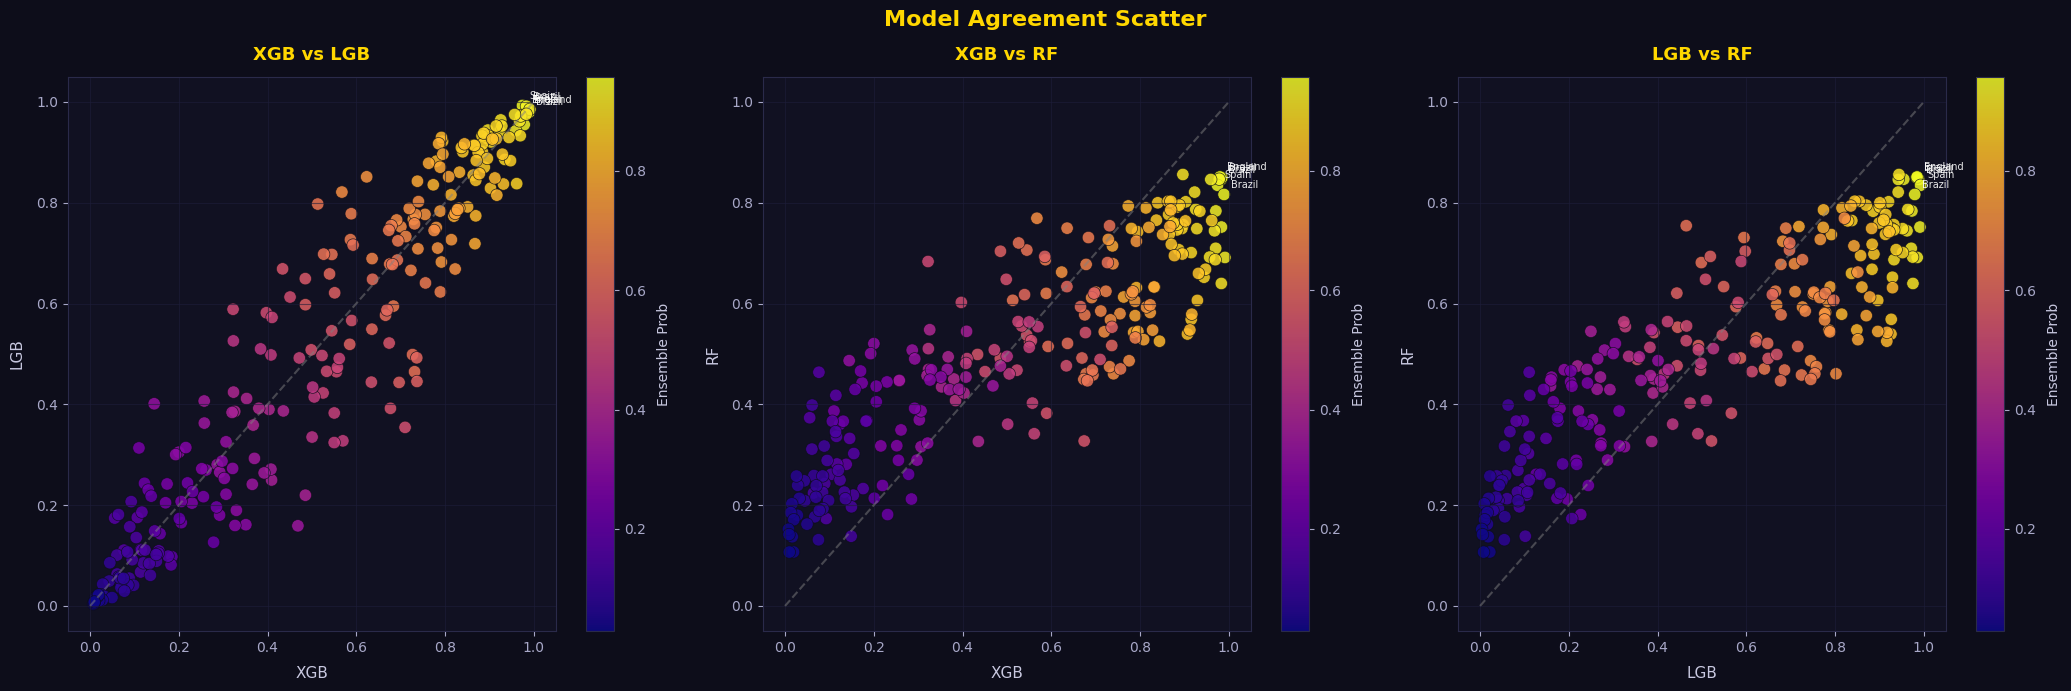

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('#0d0d1a')

pairs = [('win_prob_xgb','win_prob_lgb','XGB vs LGB'),
         ('win_prob_xgb','win_prob_rf', 'XGB vs RF'),
         ('win_prob_lgb','win_prob_rf', 'LGB vs RF')]

for ax, (x_col, y_col, title) in zip(axes, pairs):
    sc = ax.scatter(pred_df[x_col], pred_df[y_col],
                    c=pred_df['win_prob_ensemble'], cmap='plasma',
                    s=80, alpha=0.85, edgecolors='#0d0d1a', linewidths=0.5)
    ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
    ax.set_xlabel(x_col.replace('win_prob_','').upper(), fontsize=11)
    ax.set_ylabel(y_col.replace('win_prob_','').upper(), fontsize=11)
    ax.set_title(title, color=GOLD, fontsize=13, fontweight='bold')
    for _, row in pred_df.head(5).iterrows():
        ax.annotate(row['team_name'], (row[x_col], row[y_col]),
                    textcoords='offset points', xytext=(5,5),
                    fontsize=7, color='white', alpha=0.9)
    plt.colorbar(sc, ax=ax, label='Ensemble Prob')

plt.suptitle('Model Agreement Scatter', color=GOLD, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_14_model_agreement.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


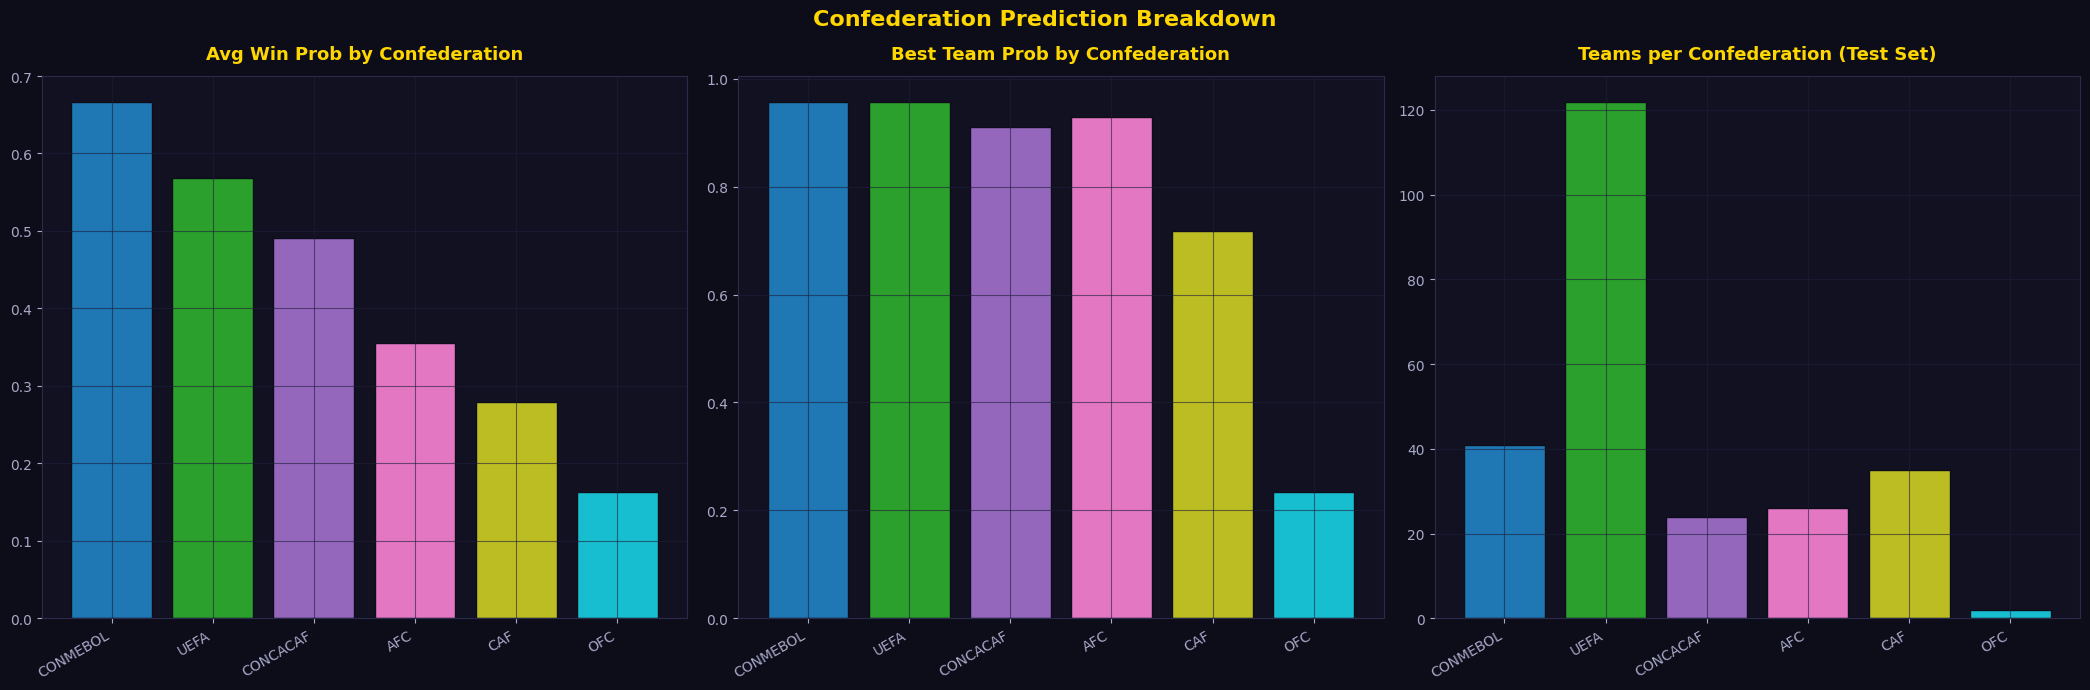

In [24]:
conf_pred = pred_df.groupby('confederation').agg(
    avg_prob=('win_prob_ensemble','mean'),
    max_prob=('win_prob_ensemble','max'),
    team_count=('team_name','count')
).reset_index().sort_values('avg_prob', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('#0d0d1a')

c_colors = plt.cm.tab10(np.linspace(0, 1, len(conf_pred)))

axes[0].bar(conf_pred['confederation'], conf_pred['avg_prob'], color=c_colors, edgecolor='#0d0d1a')
axes[0].set_title('Avg Win Prob by Confederation', color=GOLD, fontsize=13, fontweight='bold')
axes[0].set_xticklabels(conf_pred['confederation'], rotation=30, ha='right')

axes[1].bar(conf_pred['confederation'], conf_pred['max_prob'], color=c_colors, edgecolor='#0d0d1a')
axes[1].set_title('Best Team Prob by Confederation', color=GOLD, fontsize=13, fontweight='bold')
axes[1].set_xticklabels(conf_pred['confederation'], rotation=30, ha='right')
axes[2].bar(conf_pred['confederation'], conf_pred['team_count'], color=c_colors, edgecolor='#0d0d1a')
axes[2].set_title('Teams per Confederation (Test Set)', color=GOLD, fontsize=13, fontweight='bold')
axes[2].set_xticklabels(conf_pred['confederation'], rotation=30, ha='right')

plt.suptitle('Confederation Prediction Breakdown', color=GOLD, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_15_confederation_pred.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()


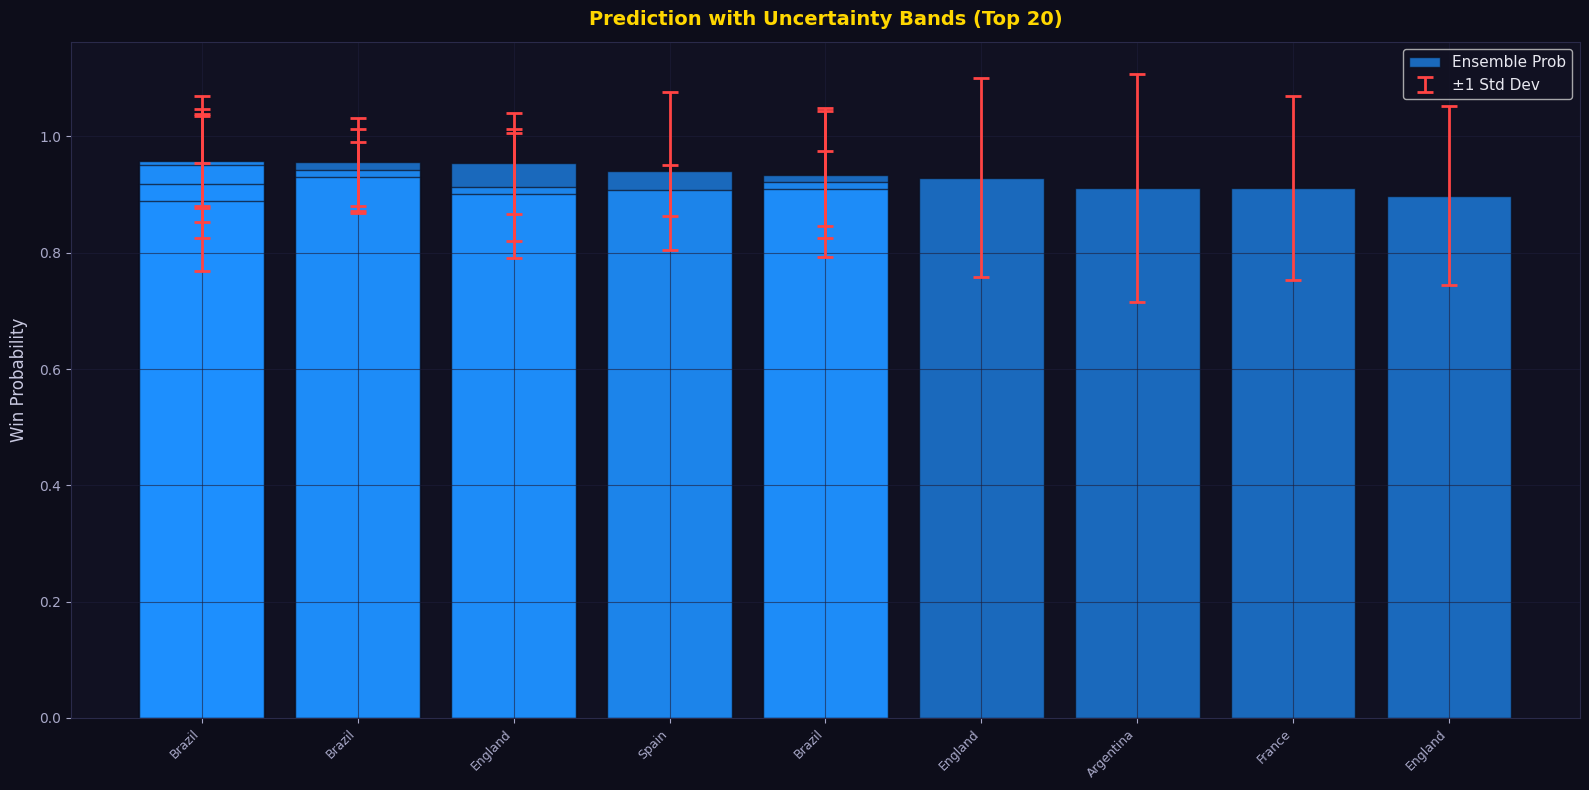

In [25]:
pred_df['uncertainty'] = pred_df[['win_prob_xgb','win_prob_lgb','win_prob_rf']].std(axis=1)
top_unc = pred_df.sort_values('win_prob_ensemble', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0d0d1a'); ax.set_facecolor('#111122')
ax.bar(top_unc['team_name'], top_unc['win_prob_ensemble'],
       color=BLUE, alpha=0.7, label='Ensemble Prob', edgecolor='#0d0d1a')
ax.errorbar(top_unc['team_name'], top_unc['win_prob_ensemble'],
            yerr=top_unc['uncertainty'], fmt='none', color=RED,
            capsize=6, capthick=2, linewidth=2, label='±1 Std Dev')
ax.set_xticklabels(top_unc['team_name'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Win Probability', fontsize=12)
ax.set_title('Prediction with Uncertainty Bands (Top 20)', color=GOLD, fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_16_uncertainty.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

In [26]:
top20_plot = pred_df.head(20).sort_values('win_prob_ensemble', ascending=True)
fig = px.bar(
    top20_plot, x='win_prob_ensemble', y='team_name',
    orientation='h', color='win_prob_ensemble',
    color_continuous_scale='plasma',
    text=top20_plot['win_prob_ensemble'].map(lambda x: f'{x:.1%}'),
    hover_data=['confederation','fifa_points','avg_player_rating','market_value_million_eur'],
    title='FIFA World Cup 2026 — Top 20 Win Probabilities (Interactive)',
    labels={'win_prob_ensemble':'Win Probability','team_name':'Team'},
    height=620,
)
fig.update_traces(textposition='outside', textfont_size=11)
fig.update_layout(
    plot_bgcolor='#111122', paper_bgcolor='#0d0d1a',
    font_color='#e8e8f0',
    title_font_color='#FFD700', title_font_size=17,
    coloraxis_showscale=True,
)
fig.show()

In [28]:

fig = px.scatter(
    pred_df,
    x='market_value_million_eur', y='win_prob_ensemble',
    color='confederation', size='avg_player_rating',
    hover_name='team_name',
    hover_data=['fifa_points','recent_form_score','win_prob_xgb','win_prob_lgb'],
    title='Market Value vs Win Probability (by Confederation)',
    labels={'market_value_million_eur':'Market Value (€M)','win_prob_ensemble':'Win Probability'},
    height=600, color_discrete_sequence=px.colors.qualitative.Bold,
)
fig.update_layout(
    plot_bgcolor='#111122', paper_bgcolor='#0d0d1a',
    font_color='#e8e8f0', title_font_color='#FFD700', title_font_size=15)
fig.show()

In [29]:
fig = px.sunburst(
    pred_df, path=['confederation','team_name'],
    values='win_prob_ensemble', color='win_prob_ensemble',
    color_continuous_scale='plasma',
    title='Win Probability Sunburst — Confederation → Team',
    height=650,
)
fig.update_layout(
    paper_bgcolor='#0d0d1a', font_color='#e8e8f0',
    title_font_color='#FFD700', title_font_size=15)
fig.show()

In [30]:
top5 = pred_df.head(5)
radar_cols = ['fifa_points','avg_player_rating','win_rate_last_year',
              'goals_scored_avg','possession_avg','recent_form_score']
labels = ['FIFA Pts','Rating','Win Rate','Goals','Possession','Form']

fig = go.Figure()
for _, row in top5.iterrows():
    vals = [(row[c] - pred_df[c].min()) /
            (pred_df[c].max() - pred_df[c].min()) for c in radar_cols]
    vals += [vals[0]]  
    fig.add_trace(go.Scatterpolar(r=vals, theta=labels+[labels[0]],
                                  fill='toself', name=row['team_name'],
                                  opacity=0.75, line_width=2))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1],
                               gridcolor='#2a2a4a', tickcolor='white'),
               angularaxis=dict(tickcolor='white', gridcolor='#2a2a4a'),
               bgcolor='#111122'),
    paper_bgcolor='#0d0d1a', font_color='#e8e8f0',
    title=dict(text='Top 5 Teams — Radar Profile', font_color='#FFD700', font_size=16),
    height=580,
)
fig.show()

In [31]:
top15 = pred_df.head(15)
hm_features = ['fifa_points','avg_player_rating','market_value_million_eur',
                'win_rate_last_year','goals_scored_avg','recent_form_score',
                'shots_per_game','possession_avg','passing_accuracy',
                'clean_sheets_last_10','experience_avg_caps']
hm_data = top15[hm_features].copy()
hm_norm  = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min())
fig = go.Figure(data=go.Heatmap(
    z=hm_norm.values,
    x=[f.replace('_',' ').title() for f in hm_features],
    y=top15['team_name'].values,
    colorscale='Plasma', text=np.round(hm_norm.values,2),
    texttemplate='%{text}', textfont_size=9,
    hovertemplate='Team: %{y}<br>Feature: %{x}<br>Norm Value: %{z:.2f}<extra></extra>'
))
fig.update_layout(
    title=dict(text='Feature Heatmap — Top 15 Teams (Normalised)',
               font_color='#FFD700', font_size=15),
    paper_bgcolor='#0d0d1a', plot_bgcolor='#111122',
    font_color='#e8e8f0', height=520,
    xaxis=dict(tickangle=-35),
)
fig.show()

In [ ]:
model_names = ['XGBoost','LightGBM','Random Forest','Gradient Boosting','Ensemble']
model_aucs  = [results[n]['AUC'] for n in model_names]
model_accs  = [results[n]['Accuracy'] for n in model_names]

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['AUC-ROC Score','Accuracy Score'])

fig.add_trace(go.Bar(name='AUC', x=model_names, y=model_aucs,
                     marker_color='#FFD700', text=[f'{v:.3f}' for v in model_aucs],
                     textposition='outside'), row=1, col=1)
fig.add_trace(go.Bar(name='Accuracy', x=model_names, y=model_accs,
                     marker_color='#1e90ff', text=[f'{v:.3f}' for v in model_accs],
                     textposition='outside'), row=1, col=2)

fig.update_layout(
    title=dict(text='Model Leaderboard', font_color='#FFD700', font_size=16),
    paper_bgcolor='#0d0d1a', plot_bgcolor='#111122', font_color='#e8e8f0',
    height=500, showlegend=False,
)
fig.update_yaxes(range=[0.5,1.05])
fig.show()

In [33]:
fig = px.scatter(
    pred_df,
    x='fifa_points', y='win_prob_ensemble',
    color='confederation', size='market_value_million_eur',
    size_max=45, hover_name='team_name',
    hover_data={'win_prob_xgb':True,'win_prob_lgb':True,'recent_form_score':True},
    text='team_name',
    title='FIFA Points vs Win Probability (Bubble = Market Value)',
    height=650, color_discrete_sequence=px.colors.qualitative.Vivid,
)
fig.update_traces(textposition='top center', textfont_size=8)
fig.update_layout(
    plot_bgcolor='#111122', paper_bgcolor='#0d0d1a',
    font_color='#e8e8f0', title_font_color='#FFD700', title_font_size=15)
fig.show()

In [34]:

submission = pd.DataFrame({
    'id'                : range(len(test_proba)),
    'winner_probability': test_proba
})
submission.to_csv('submission_final.csv', index=False)

print("Submission saved: submission_final.csv")
print(f"Shape: {submission.shape}")
print("\nPreview:")
print(submission.head(10))
print("\nStats:")
print(submission['winner_probability'].describe())


Submission saved: submission_final.csv
Shape: (250, 2)

Preview:
   id  winner_probability
0   0            0.940246
1   1            0.632829
2   2            0.600945
3   3            0.084594
4   4            0.722007
5   5            0.678125
6   6            0.901752
7   7            0.929998
8   8            0.267277
9   9            0.618029

Stats:
count    250.000000
mean       0.511253
std        0.288182
min        0.028482
25%        0.244087
50%        0.534139
75%        0.779099
max        0.957874
Name: winner_probability, dtype: float64


In [35]:

pg_schema = '''
-- ============================================================
--  FIFA World Cup 2026 Prediction Dashboard — PostgreSQL DDL
-- ============================================================

-- 1. Teams dimension table
CREATE TABLE teams (
    team_id          SERIAL PRIMARY KEY,
    team_name        VARCHAR(100) NOT NULL UNIQUE,
    country_code     CHAR(3),
    confederation    VARCHAR(20)
);

-- 2. Raw features table (training data)
CREATE TABLE team_features (
    feature_id               SERIAL PRIMARY KEY,
    team_id                  INT REFERENCES teams(team_id) ON DELETE CASCADE,
    split                    VARCHAR(10) DEFAULT 'train',  -- train / test
    fifa_rank                SMALLINT,
    fifa_points              NUMERIC(7,2),
    wins_last_10_matches     SMALLINT,
    losses_last_10_matches   SMALLINT,
    draws_last_10_matches    SMALLINT,
    win_rate_last_year       NUMERIC(5,4),
    goals_scored_avg         NUMERIC(5,3),
    goals_conceded_avg       NUMERIC(5,3),
    clean_sheets_last_10     SMALLINT,
    shots_per_game           NUMERIC(5,2),
    shots_on_target_ratio    NUMERIC(5,4),
    avg_player_rating        NUMERIC(5,2),
    star_players_count       SMALLINT,
    market_value_million_eur NUMERIC(8,2),
    experience_avg_caps      SMALLINT,
    coach_experience_years   SMALLINT,
    recent_form_score        NUMERIC(5,3),
    possession_avg           NUMERIC(5,2),
    passing_accuracy         NUMERIC(5,2),
    host_advantage           SMALLINT,
    travel_distance_avg      NUMERIC(6,2),
    climate_similarity_score NUMERIC(5,4),
    winner                   SMALLINT   -- 1 = winner, 0 = not winner, NULL for test
);

-- 3. Engineered features table
CREATE TABLE engineered_features (
    ef_id                  SERIAL PRIMARY KEY,
    team_id                INT REFERENCES teams(team_id),
    strength_index         NUMERIC(10,4),
    goal_efficiency        NUMERIC(8,4),
    attack_potency         NUMERIC(8,4),
    defensive_solidity     NUMERIC(8,4),
    squad_quality          NUMERIC(8,4),
    form_consistency       NUMERIC(8,4),
    possession_dominance   NUMERIC(8,4),
    star_power             NUMERIC(12,2),
    contextual_advantage   NUMERIC(8,4),
    goals_diff_avg         NUMERIC(6,4),
    consistency_score      SMALLINT,
    experience_rank        NUMERIC(10,4)
);

-- 4. Model predictions table
CREATE TABLE model_predictions (
    pred_id              SERIAL PRIMARY KEY,
    team_id              INT REFERENCES teams(team_id),
    model_name           VARCHAR(50),       -- XGBoost, LightGBM, RF, Ensemble
    win_probability      NUMERIC(8,6),
    created_at           TIMESTAMP DEFAULT NOW()
);

-- 5. Model metadata table
CREATE TABLE model_runs (
    run_id          SERIAL PRIMARY KEY,
    model_name      VARCHAR(50),
    val_auc         NUMERIC(6,4),
    val_accuracy    NUMERIC(6,4),
    cv_auc_mean     NUMERIC(6,4),
    cv_auc_std      NUMERIC(6,4),
    n_estimators    INT,
    hyperparams     JSONB,
    trained_at      TIMESTAMP DEFAULT NOW()
);

-- 6. Indexes for dashboard performance
CREATE INDEX idx_teams_confederation ON teams(confederation);
CREATE INDEX idx_features_team       ON team_features(team_id);
CREATE INDEX idx_predictions_model   ON model_predictions(model_name);
CREATE INDEX idx_predictions_team    ON model_predictions(team_id);

-- ============================================================
-- USEFUL DASHBOARD QUERIES
-- ============================================================

-- Q1: Top 10 predicted winners (ensemble)
-- SELECT t.team_name, t.confederation,
--        mp.win_probability
-- FROM model_predictions mp
-- JOIN teams t ON t.team_id = mp.team_id
-- WHERE mp.model_name = 'Ensemble'
-- ORDER BY mp.win_probability DESC
-- LIMIT 10;

-- Q2: Average win probability by confederation
-- SELECT t.confederation,
--        AVG(mp.win_probability)  AS avg_prob,
--        MAX(mp.win_probability)  AS best_team_prob,
--        COUNT(DISTINCT t.team_id) AS teams
-- FROM model_predictions mp
-- JOIN teams t ON t.team_id = mp.team_id
-- WHERE mp.model_name = 'Ensemble'
-- GROUP BY t.confederation
-- ORDER BY avg_prob DESC;

-- Q3: Model leaderboard
-- SELECT model_name, val_auc, val_accuracy, cv_auc_mean
-- FROM model_runs
-- ORDER BY val_auc DESC;

-- Q4: Correlation of market value with win probability
-- SELECT t.team_name,
--        tf.market_value_million_eur,
--        mp.win_probability
-- FROM model_predictions mp
-- JOIN teams t  ON t.team_id  = mp.team_id
-- JOIN team_features tf ON tf.team_id = mp.team_id
-- WHERE mp.model_name = 'Ensemble' AND tf.split = 'test'
-- ORDER BY mp.win_probability DESC;
'''
print(pg_schema)

with open('wc2026_schema.sql', 'w') as f:
    f.write(pg_schema)
print("\nPostgreSQL schema saved: wc2026_schema.sql")



-- ============================================================
--  FIFA World Cup 2026 Prediction Dashboard — PostgreSQL DDL
-- ============================================================

-- 1. Teams dimension table
CREATE TABLE teams (
    team_id          SERIAL PRIMARY KEY,
    team_name        VARCHAR(100) NOT NULL UNIQUE,
    country_code     CHAR(3),
    confederation    VARCHAR(20)
);

-- 2. Raw features table (training data)
CREATE TABLE team_features (
    feature_id               SERIAL PRIMARY KEY,
    team_id                  INT REFERENCES teams(team_id) ON DELETE CASCADE,
    split                    VARCHAR(10) DEFAULT 'train',  -- train / test
    fifa_rank                SMALLINT,
    fifa_points              NUMERIC(7,2),
    wins_last_10_matches     SMALLINT,
    losses_last_10_matches   SMALLINT,
    draws_last_10_matches    SMALLINT,
    win_rate_last_year       NUMERIC(5,4),
    goals_scored_avg         NUMERIC(5,3),
    goals_conceded_avg       NUMERIC(5,3),


In [36]:
def generate_inserts(pred_df):
    lines = [
        "-- Auto-generated INSERT statements for model_predictions",
        "BEGIN;",
        "",
        "-- Insert teams first (dedup via ON CONFLICT)",
    ]
    for _, row in pred_df.iterrows():
        lines.append(
            f"INSERT INTO teams (team_name, country_code, confederation) "
            f"VALUES ('{row.team_name}', '{row.country_code}', '{row.confederation}') "
            f"ON CONFLICT (team_name) DO NOTHING;"
        )
    lines += ["", "-- Insert ensemble predictions"]
    for i, row in pred_df.iterrows():
        lines.append(
            f"INSERT INTO model_predictions (team_id, model_name, win_probability) "
            f"SELECT team_id, 'Ensemble', {row.win_prob_ensemble:.6f} "
            f"FROM teams WHERE team_name = '{row.team_name}';"
        )
    lines += ["", "COMMIT;"]
    return "\n".join(lines)

sql_inserts = generate_inserts(pred_df)
with open('wc2026_inserts.sql', 'w') as f:
    f.write(sql_inserts)
print("INSERT statements saved: wc2026_inserts.sql")
print("Preview (first 20 lines):")
for line in sql_inserts.split('\n')[:20]:
    print(line)


INSERT statements saved: wc2026_inserts.sql
Preview (first 20 lines):
-- Auto-generated INSERT statements for model_predictions
BEGIN;

-- Insert teams first (dedup via ON CONFLICT)
INSERT INTO teams (team_name, country_code, confederation) VALUES ('Brazil', 'BRA', 'CONMEBOL') ON CONFLICT (team_name) DO NOTHING;
INSERT INTO teams (team_name, country_code, confederation) VALUES ('Brazil', 'BRA', 'CONMEBOL') ON CONFLICT (team_name) DO NOTHING;
INSERT INTO teams (team_name, country_code, confederation) VALUES ('England', 'ENG', 'UEFA') ON CONFLICT (team_name) DO NOTHING;
INSERT INTO teams (team_name, country_code, confederation) VALUES ('Spain', 'ESP', 'UEFA') ON CONFLICT (team_name) DO NOTHING;
INSERT INTO teams (team_name, country_code, confederation) VALUES ('Brazil', 'BRA', 'CONMEBOL') ON CONFLICT (team_name) DO NOTHING;
INSERT INTO teams (team_name, country_code, confederation) VALUES ('England', 'ENG', 'UEFA') ON CONFLICT (team_name) DO NOTHING;
INSERT INTO teams (team_name, country

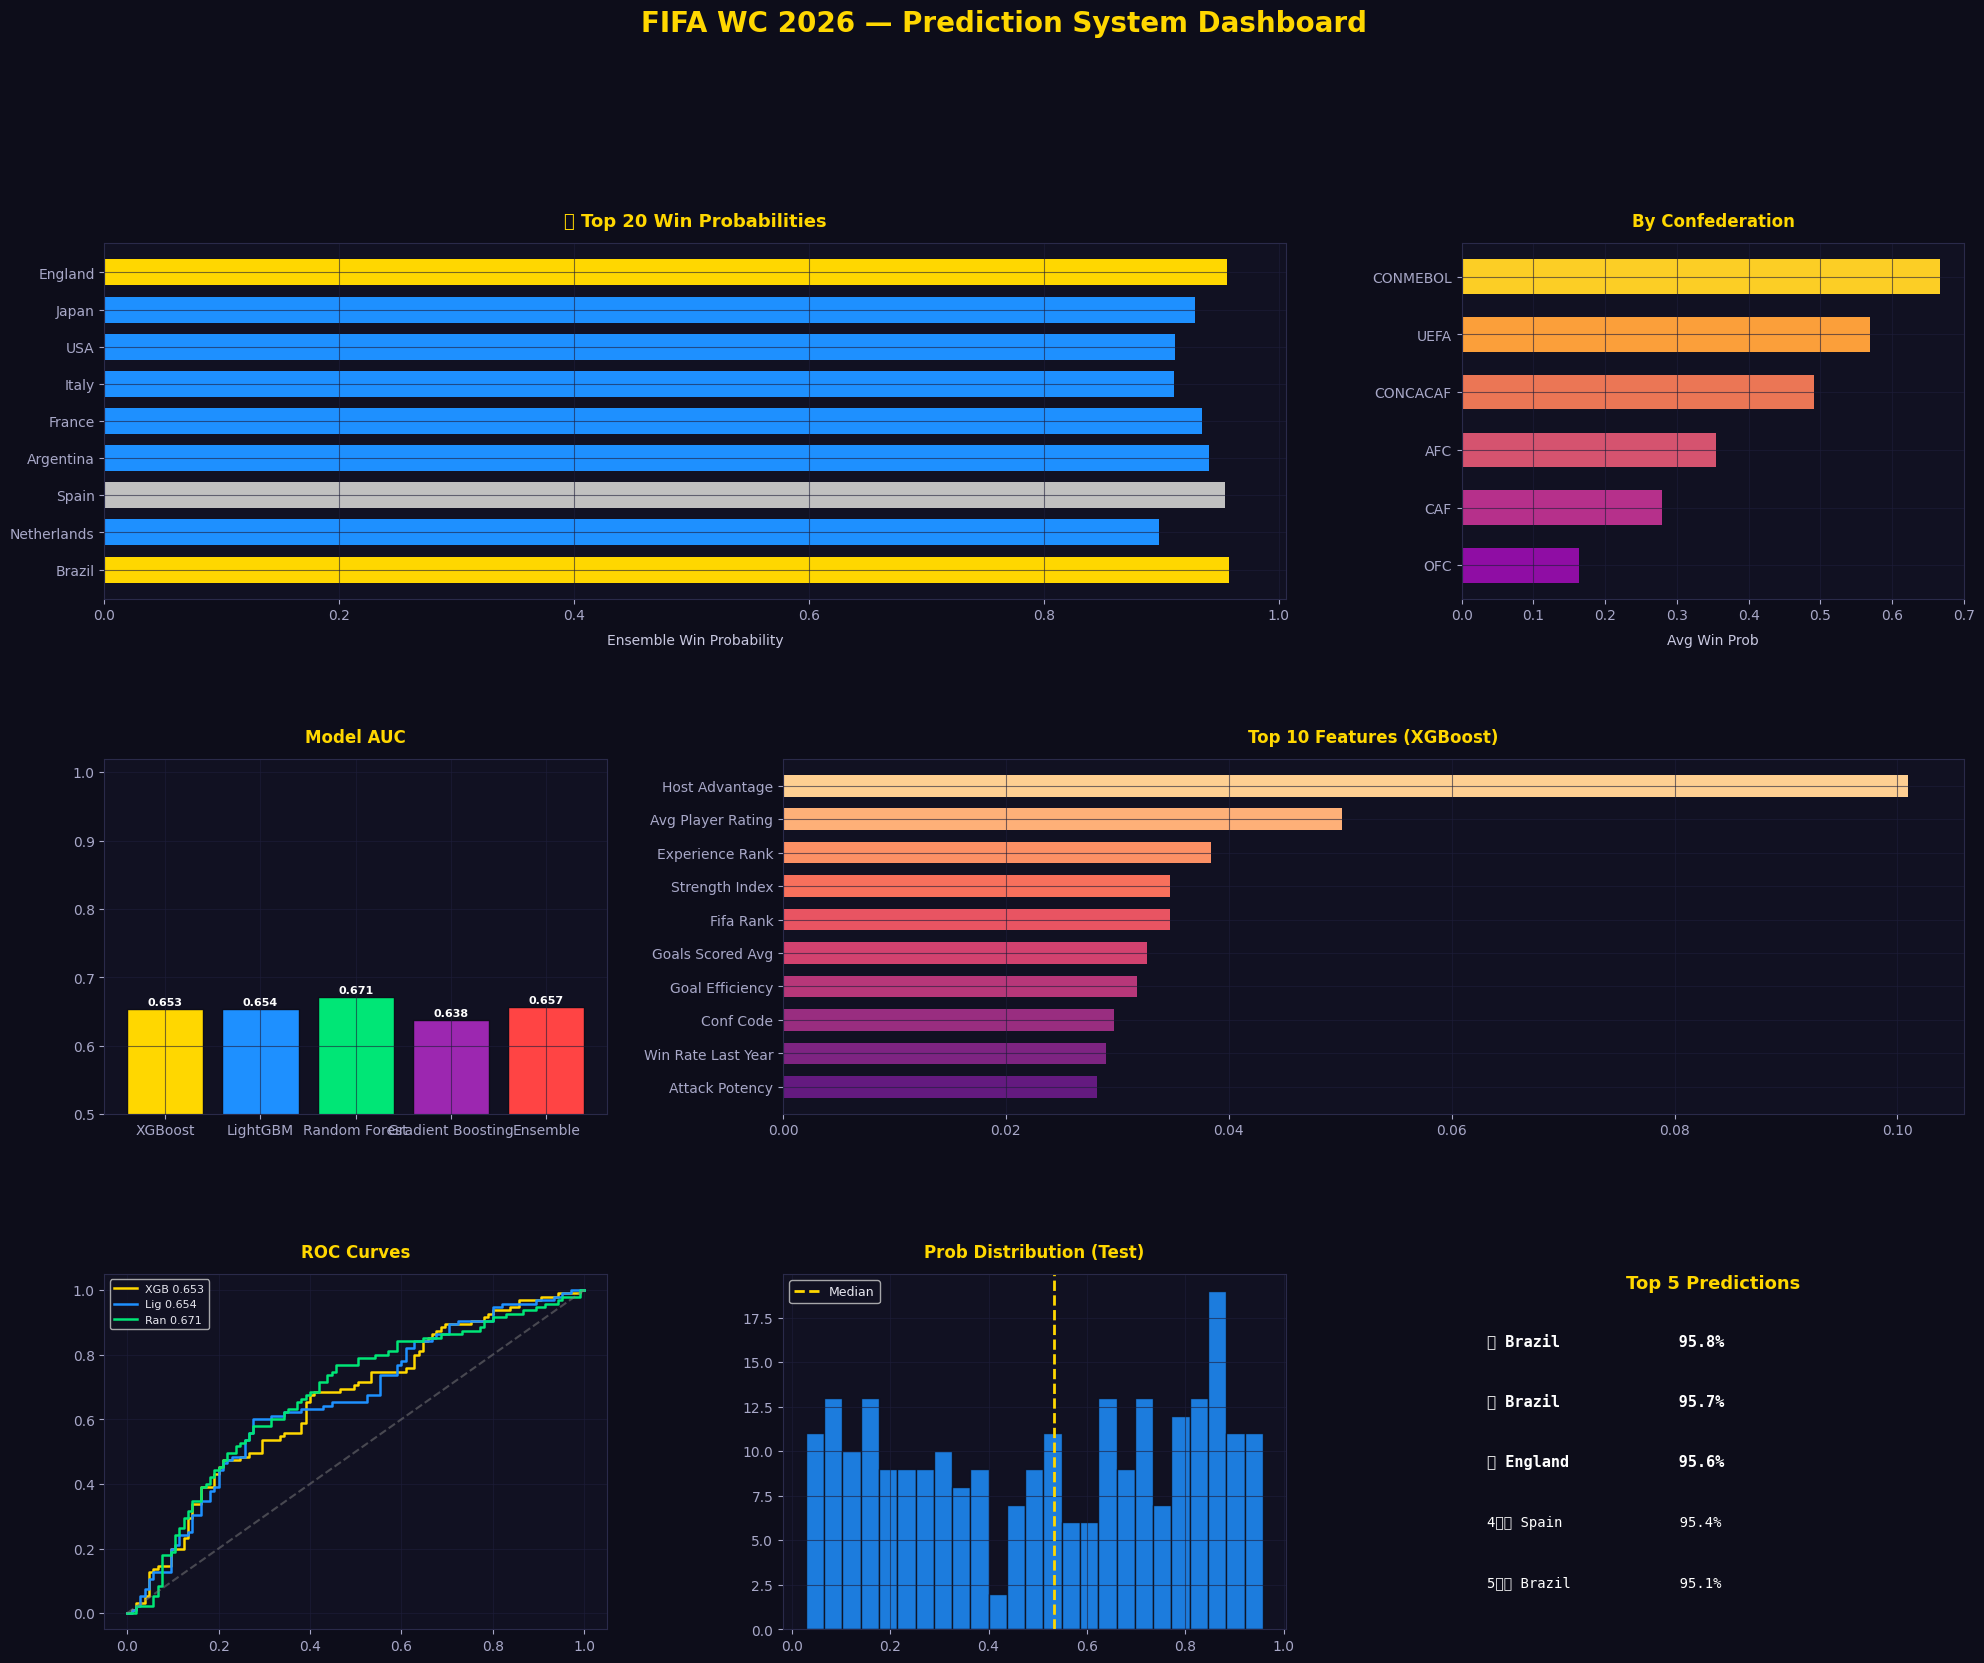

Final dashboard saved: plot_17_final_dashboard.png


In [37]:

top5 = pred_df.head(5)
fig = plt.figure(figsize=(24, 18))
fig.patch.set_facecolor('#0d0d1a')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
ax_a = fig.add_subplot(gs[0, :2])
top20s = pred_df.head(20).sort_values('win_prob_ensemble', ascending=True)
colors_a = [GOLD if i >= 17 else (SILVER if i >= 15 else BLUE) for i in range(20)]
ax_a.barh(top20s['team_name'], top20s['win_prob_ensemble'], color=colors_a, height=0.7)
ax_a.set_title('🏆 Top 20 Win Probabilities', color=GOLD, fontsize=13, fontweight='bold')
ax_a.set_xlabel('Ensemble Win Probability')
ax_b = fig.add_subplot(gs[0, 2])
conf_s = (pred_df.groupby('confederation')['win_prob_ensemble']
          .mean().sort_values(ascending=False))
ax_b.barh(conf_s.index[::-1], conf_s.values[::-1],
          color=plt.cm.plasma(np.linspace(0.3,0.9,len(conf_s))), height=0.6)
ax_b.set_title('By Confederation', color=GOLD, fontsize=12, fontweight='bold')
ax_b.set_xlabel('Avg Win Prob')
ax_c = fig.add_subplot(gs[1, 0])
mn = [n for n in model_names]
bars_c = ax_c.bar(mn, model_aucs, color=[GOLD,BLUE,GREEN,PURPLE,RED], edgecolor='#0d0d1a')
ax_c.set_ylim(0.5, 1.02)
ax_c.set_title('Model AUC', color=GOLD, fontsize=12, fontweight='bold')
for bar, v in zip(bars_c, model_aucs):
    ax_c.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
              ha='center', color='white', fontsize=8, fontweight='bold')
ax_d = fig.add_subplot(gs[1, 1:])
imp_top10 = imp_xgb.head(10).sort_values('importance')
ax_d.barh(imp_top10['feature'].str.replace('_',' ').str.title(),
          imp_top10['importance'],
          color=plt.cm.magma(np.linspace(0.3,0.9,10)), height=0.65)
ax_d.set_title('Top 10 Features (XGBoost)', color=GOLD, fontsize=12, fontweight='bold')
ax_e = fig.add_subplot(gs[2, 0])
for (name, res), col in zip(list(results.items())[:3], [GOLD,BLUE,GREEN]):
    fpr, tpr, _ = roc_curve(y_val, res['proba'])
    ax_e.plot(fpr, tpr, color=col, lw=1.8, label=f'{name[:3]} {res["AUC"]:.3f}')
ax_e.plot([0,1],[0,1],'--',color='gray',alpha=0.5)
ax_e.set_title('ROC Curves', color=GOLD, fontsize=12, fontweight='bold')
ax_e.legend(fontsize=8)
ax_f = fig.add_subplot(gs[2, 1])
ax_f.hist(pred_df['win_prob_ensemble'], bins=25, color=BLUE, edgecolor='#0d0d1a', alpha=0.85)
ax_f.axvline(pred_df['win_prob_ensemble'].median(), color=GOLD, lw=2, linestyle='--', label='Median')
ax_f.set_title('Prob Distribution (Test)', color=GOLD, fontsize=12, fontweight='bold')
ax_f.legend(fontsize=9)
ax_g = fig.add_subplot(gs[2, 2])
ax_g.axis('off')
ax_g.set_facecolor('#111122')
medals = ['🥇','🥈','🥉','4️⃣','5️⃣']
ax_g.text(0.5, 1.0, 'Top 5 Predictions', transform=ax_g.transAxes,
          ha='center', va='top', color=GOLD, fontsize=13, fontweight='bold')
for j, (_, row) in enumerate(top5.iterrows()):
    ax_g.text(0.05, 0.80 - j*0.17,
              f"{medals[j]} {row['team_name']:<18} {row['win_prob_ensemble']:.1%}",
              transform=ax_g.transAxes, color='white',
              fontsize=11 if j < 3 else 10, fontweight='bold' if j < 3 else 'normal',
              fontfamily='monospace')

plt.suptitle('FIFA WC 2026 — Prediction System Dashboard',
             color=GOLD, fontsize=20, fontweight='bold', y=1.01)

plt.savefig('plot_17_final_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print("Final dashboard saved: plot_17_final_dashboard.png")


In [38]:
import numpy as np
import pandas as pd
import random


TEAM_RATINGS = {
    "USA":           79,
    "Canada":        74,
    "Mexico":        77,
    "France":        91,
    "England":       90,
    "Spain":         89,
    "Germany":       88,
    "Portugal":      87,
    "Netherlands":   85,
    "Italy":         84,
    "Belgium":       83,
    "Croatia":       82,
    "Switzerland":   81,
    "Denmark":       80,
    "Austria":       79,
    "Turkey":        78,
    "Poland":        77,
    "Serbia":        76,
    "Ukraine":       75,
    "Morocco":       81,
    "Senegal":       79,
    "Nigeria":       78,
    "Egypt":         77,
    "Cameroon":      76,
    "Ghana":         75,
    "Algeria":       76,
    "Tunisia":       74,
    "Ivory Coast":   75,
    "Japan":         83,
    "South Korea":   80,
    "Iran":          78,
    "Saudi Arabia":  76,
    "Australia":     78,
    "Iraq":          73,
    "UAE":           74,
    "Qatar":         76,
    "Brazil":        92,
    "Argentina":     93,
    "Uruguay":       83,
    "Colombia":      82,
    "Ecuador":       78,
    "Chile":         76,

    "Costa Rica":    74,
    "Panama":        72,
    "Jamaica":       70,

    "New Zealand":   71,

    "Peru":          74,
    "Uzbekistan":    72,
}

# =============================================================
# 2. GROUP DRAW — 12 GROUPS OF 4
#    Simulated draw respecting FIFA confederation rules:
#      • Max 2 UEFA teams per group
#      • Max 1 team from any other confederation per group
# =============================================================

GROUPS = {
    "A": ["USA",          "Ecuador",      "Senegal",      "Iraq"],
    "B": ["Mexico",       "Chile",        "Iran",         "Austria"],
    "C": ["Canada",       "Colombia",     "Nigeria",      "Poland"],
    "D": ["Brazil",       "Serbia",       "Egypt",        "Panama"],
    "E": ["France",       "Uruguay",      "Australia",    "Costa Rica"],
    "F": ["England",      "Peru",         "Saudi Arabia", "Ivory Coast"],
    "G": ["Spain",        "Argentina",    "South Korea",  "Croatia"],
    "H": ["Portugal",     "Turkey",       "Morocco",      "UAE"],
    "I": ["Netherlands",  "Ukraine",      "Ghana",        "Jamaica"],
    "J": ["Germany",      "Italy",        "Japan",        "Algeria"],
    "K": ["Belgium",      "Denmark",      "Tunisia",      "Qatar"],
    "L": ["Switzerland",  "Uzbekistan",   "New Zealand",  "Cameroon"],
}

# =============================================================
# 3. MATCH ENGINE — POISSON GOAL MODEL
# =============================================================

def simulate_match(team_a, team_b, knockout=False):
    """
    Simulate a football match using a Poisson-distributed goal model.

    Expected goals are derived from the rating difference between
    the two teams, anchored to the World Cup average of ~1.35
    goals per team per match.

    In knockout mode, draws are resolved via a simplified
    extra-time / penalty shootout model.

    Returns:
        (goals_a, goals_b, result_str)
        result_str: "W" (A wins), "L" (B wins), "D" (draw)
    """
    ra = TEAM_RATINGS[team_a]
    rb = TEAM_RATINGS[team_b]
    diff = ra - rb

    # Expected goals per team
    lambda_a = max(0.05, 1.35 + diff / 35.0)
    lambda_b = max(0.05, 1.35 - diff / 35.0)

    goals_a = int(np.random.poisson(lambda_a))
    goals_b = int(np.random.poisson(lambda_b))

    # Knockout: resolve draws (extra time / penalties)
    if knockout and goals_a == goals_b:
        prob_a = 1.0 / (1.0 + np.exp(-diff / 10.0))
        if random.random() < prob_a:
            goals_a += 1
        else:
            goals_b += 1

    if goals_a > goals_b:
        result = "W"
    elif goals_a < goals_b:
        result = "L"
    else:
        result = "D"

    return goals_a, goals_b, result

# =============================================================
# 4. GROUP STAGE SIMULATION
# =============================================================

def simulate_group_stage(verbose=True):
    """Simulate all 12 groups (round-robin, 6 matches each)."""
    all_groups = {}

    for gname, teams in GROUPS.items():
        stats = {t: {"pts": 0, "gf": 0, "ga": 0, "w": 0, "d": 0, "l": 0}
                 for t in teams}
        matches = []

        for i in range(4):
            for j in range(i + 1, 4):
                ta, tb = teams[i], teams[j]
                ga, gb, res = simulate_match(ta, tb)
                matches.append((ta, tb, ga, gb))

                stats[ta]["gf"] += ga;  stats[ta]["ga"] += gb
                stats[tb]["gf"] += gb;  stats[tb]["ga"] += ga

                if res == "W":
                    stats[ta]["pts"] += 3;  stats[ta]["w"] += 1;  stats[tb]["l"] += 1
                elif res == "L":
                    stats[tb]["pts"] += 3;  stats[tb]["w"] += 1;  stats[ta]["l"] += 1
                else:
                    stats[ta]["pts"] += 1;  stats[ta]["d"] += 1
                    stats[tb]["pts"] += 1;  stats[tb]["d"] += 1

        for t in teams:
            stats[t]["gd"] = stats[t]["gf"] - stats[t]["ga"]

        # FIFA tiebreakers: Points → Goal Difference → Goals Scored
        ranking = sorted(teams,
                         key=lambda t: (stats[t]["pts"], stats[t]["gd"], stats[t]["gf"]),
                         reverse=True)

        if verbose:
            print(f"\n{'═' * 60}")
            print(f"  GROUP {gname}")
            print(f"{'═' * 60}")
            print(f"  {'#':<3} {'Team':<16} {'MP':>3} {'W':>3} {'D':>3} {'L':>3}"
                  f" {'GF':>4} {'GA':>4} {'GD':>5} {'Pts':>5}")
            print(f"  {'─' * 60}")
            for idx, t in enumerate(ranking, 1):
                s = stats[t]
                tag = " ✅" if idx <= 2 else (" ⏳" if idx == 3 else " ❌")
                print(f"  {idx:<3} {t:<16} {3:>3} {s['w']:>3} {s['d']:>3} {s['l']:>3}"
                      f" {s['gf']:>4} {s['ga']:>4} {s['gd']:>+5} {s['pts']:>5}{tag}")

            print(f"\n  Match Results:")
            for ta, tb, ga, gb in matches:
                print(f"    {ta:<16} {ga} - {gb} {tb}")

        all_groups[gname] = {"ranking": ranking, "stats": stats}

    return all_groups

# =============================================================
# 5. ROUND OF 32 QUALIFICATION
# =============================================================

def get_round_of_32(all_groups, verbose=True):
    """
    Top 2 from each group (24) + 8 best 3rd-placed teams = 32.
    Tiebreakers for 3rd place: Pts → GD → GF.
    """
    auto_qualifiers = []
    third_pool = []

    for gname in sorted(all_groups.keys()):
        ranking = all_groups[gname]["ranking"]
        stats   = all_groups[gname]["stats"]

        auto_qualifiers.extend(ranking[:2])

        third = ranking[2]
        third_pool.append((third, stats[third]["pts"],
                           stats[third]["gd"], stats[third]["gf"], gname))

    third_pool.sort(key=lambda x: (x[1], x[2], x[3]), reverse=True)
    best_third     = [x[0] for x in third_pool[:8]]
    eliminated_third = [x[0] for x in third_pool[8:]]
    r32 = auto_qualifiers + best_third

    if verbose:
        print(f"\n{'═' * 60}")
        print(f"  ROUND OF 32 — QUALIFICATION SUMMARY")
        print(f"{'═' * 60}")
        print(f"\n  🟢 Best 3rd-Place Teams (advance to R32):")
        for t, pts, gd, gf, g in third_pool[:8]:
            print(f"     {t:<16} (Group {g})  —  {pts} pts, GD {gd:+d}")
        print(f"\n  🔴 Eliminated 3rd-Place Teams:")
        for t, pts, gd, gf, g in third_pool[8:]:
            print(f"     {t:<16} (Group {g})  —  {pts} pts, GD {gd:+d}")
        print(f"\n  📊 Total Round of 32 teams: {len(r32)}")

    return r32, best_third, eliminated_third

# =============================================================
# 6. KNOCKOUT ROUND ENGINE
# =============================================================

def play_knockout_round(team_list, round_name, verbose=True):
    """Play a knockout round. Returns (winners, losers, results)."""
    if verbose:
        print(f"\n{'═' * 60}")
        print(f"  {round_name}")
        print(f"{'═' * 60}")
        print(f"  {'#':<4} {'Team A':<16} {'':>2}{'Score':>7}{'':>2} "
              f"{'Team B':<16}  {'Winner'}")
        print(f"  {'─' * 60}")

    winners, losers, results = [], [], []

    for i in range(0, len(team_list), 2):
        ta, tb = team_list[i], team_list[i + 1]
        ga, gb, _ = simulate_match(ta, tb, knockout=True)
        winner = ta if ga > gb else tb
        loser  = tb if winner == ta else ta

        winners.append(winner)
        losers.append(loser)
        results.append((ta, tb, ga, gb, winner))

        if verbose:
            m = i // 2 + 1
            print(f"  {m:<4} {ta:<16} {'':>2}{ga} - {gb}{'':>2} "
                  f"{tb:<16}  → {winner}")

    return winners, losers, results

# =============================================================
# 7. FULL WORLD CUP SIMULATION
# =============================================================

def world_cup_simulation(verbose=True, seed=None):
    """Run a complete FIFA World Cup 2026 simulation."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    if verbose:
        banner = "  🏆  FIFA WORLD CUP 2026 — FULL SIMULATION  🏆"
        print(f"\n{'═' * 60}")
        print(banner)
        print(f"  Hosted by USA · CANADA · MEXICO")
        print(f"  48 Teams  |  12 Groups  |  R32 → Final")
        print(f"{'═' * 60}")

    # ── Group Stage ──
    all_groups = simulate_group_stage(verbose=verbose)

    # ── Round of 32 Qualification ──
    r32, _, _ = get_round_of_32(all_groups, verbose=verbose)

    # ── Knockout Bracket ──
    random.shuffle(r32)
    r16, _, _ = play_knockout_round(r32,  "ROUND OF 32",     verbose=verbose)
    r8,  _, _ = play_knockout_round(r16,  "ROUND OF 16",     verbose=verbose)
    r4,  _, _ = play_knockout_round(r8,   "QUARTER-FINALS",  verbose=verbose)
    sf_w, sf_l, _ = play_knockout_round(r4, "SEMI-FINALS",   verbose=verbose)

    # ── 3rd Place Playoff ──
    ga3, gb3, _ = simulate_match(sf_l[0], sf_l[1], knockout=True)
    third = sf_l[0] if ga3 > gb3 else sf_l[1]
    if verbose:
        print(f"\n{'═' * 60}")
        print(f"  3RD PLACE PLAYOFF")
        print(f"{'═' * 60}")
        print(f"  {sf_l[0]:<16} {ga3} - {gb3} {sf_l[1]:<16}")
        print(f"  🥉 3rd Place: {third}")

    # ── Final ──
    gaf, gbf, _ = simulate_match(sf_w[0], sf_w[1], knockout=True)
    champion  = sf_w[0] if gaf > gbf else sf_w[1]
    runner_up = sf_w[1] if champion == sf_w[0] else sf_w[0]

    if verbose:
        print(f"\n{'🏆' * 30}")
        print(f"                      FINAL")
        print(f"{'🏆' * 30}")
        print(f"  {sf_w[0]:<16} {gaf} - {gbf} {sf_w[1]:<16}")
        print(f"\n  🏆  WORLD CHAMPION :  {champion}")
        print(f"  🥈  RUNNER-UP      :  {runner_up}")
        print(f"  🥉  THIRD PLACE    :  {third}")
        print(f"{'🏆' * 30}\n")

    return {"champion": champion, "runner_up": runner_up, "third": third}

# =============================================================
# 8. MONTE CARLO ANALYSIS (Silent Multi-Run)
# =============================================================

def monte_carlo(n=1000, seed=42):
    """
    Run N full tournament simulations silently and return
    an aggregated statistics DataFrame.
    """
    champions, runners_up, thirds = [], [], []

    for i in range(n):
        s = seed + i if seed is not None else None
        r = world_cup_simulation(verbose=False, seed=s)
        champions.append(r["champion"])
        runners_up.append(r["runner_up"])
        thirds.append(r["third"])

    c_cnt = pd.Series(champions).value_counts()
    r_cnt = pd.Series(runners_up).value_counts()
    t_cnt = pd.Series(thirds).value_counts()

    rows = []
    for t in sorted(TEAM_RATINGS.keys()):
        rows.append({
            "Team":     t,
            "Rating":   TEAM_RATINGS[t],
            "Champion": int(c_cnt.get(t, 0)),
            "Runner-Up": int(r_cnt.get(t, 0)),
            "3rd Place": int(t_cnt.get(t, 0)),
        })

    df = pd.DataFrame(rows)
    df["Podium"]  = df["Champion"] + df["Runner-Up"] + df["3rd Place"]
    df["Win %"]   = (df["Champion"] / n * 100).round(1)
    df["Pod %"]   = (df["Podium"]   / n * 100).round(1)
    df = df.sort_values(
        ["Champion", "Runner-Up", "3rd Place"], ascending=False
    ).reset_index(drop=True)
    df.index += 1
    return df, n

# =============================================================
# 9. DISPLAY MONTE CARLO RESULTS
# =============================================================

def display_monte_carlo(df, n):
    """Pretty-print Monte Carlo results."""
    sep = "  " + "─" * 68
    print(f"\n{'═' * 72}")
    print(f"  📊  MONTE CARLO ANALYSIS  —  {n:,} SIMULATIONS")
    print(f"{'═' * 72}")
    print(f"  {'#':<4} {'Team':<16} {'Rtg':>4} {'Wins':>5} {'RU':>4}"
          f" {'3rd':>4} {'Pod':>4} {'Win%':>7} {'Pod%':>7}")
    print(sep)

    shown = 0
    for idx, row in df.iterrows():
        if row["Champion"] > 0 or row["Podium"] >= 5:
            print(f"  {idx:<4} {row['Team']:<16} {row['Rating']:>4}"
                  f" {row['Champion']:>5} {row['Runner-Up']:>4}"
                  f" {row['3rd Place']:>4} {row['Podium']:>4}"
                  f" {row['Win %']:>6.1f}% {row['Pod %']:>6.1f}%")
            shown += 1
        if shown >= 25:
            break

    if shown < len(df):
        print(f"\n  ... and {len(df) - shown} more teams with 0 podium finishes.")

    top = df.iloc[0]
    print(f"\n  🏆  Most Likely Champion:  {top['Team']}"
          f"  ({top['Win %']}% win rate)")
    print(f"{'═' * 72}\n")

# =============================================================
# 10. MAIN ENTRY POINT
# =============================================================

if __name__ == "__main__":

    # ── Run a single full simulation ──
    result = world_cup_simulation(verbose=True, seed=None)

    # ── Run Monte Carlo analysis (1,000 simulations) ──
    df_mc, n_sims = monte_carlo(n=1000, seed=42)
    display_monte_carlo(df_mc, n_sims)


════════════════════════════════════════════════════════════
  🏆  FIFA WORLD CUP 2026 — FULL SIMULATION  🏆
  Hosted by USA · CANADA · MEXICO
  48 Teams  |  12 Groups  |  R32 → Final
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  GROUP A
════════════════════════════════════════════════════════════
  #   Team              MP   W   D   L   GF   GA    GD   Pts
  ────────────────────────────────────────────────────────────
  1   USA                3   1   2   0    6    3    +3     5 ✅
  2   Senegal            3   1   2   0    6    4    +2     5 ✅
  3   Ecuador            3   1   2   0    5    3    +2     5 ⏳
  4   Iraq               3   0   0   3    2    9    -7     0 ❌

  Match Results:
    USA              1 - 1 Ecuador
    USA              2 - 2 Senegal
    USA              3 - 0 Iraq
    Ecuador          1 - 1 Senegal
    Ecuador          3 - 1 Iraq
    Senegal          3 - 1 Iraq

═══════════════════════════